# Positioning for Inflation Surprises — An Empirical Study

By JX (with the help of Claude Opus 5), 2026-09-17

This is a replication of earlier my earlier work done in March 2022.

Bloomberg tickers replaced by publicly available equivalents — and extends the sample by the time that has since passed (which includes the post-Covid inflation spike). 

Study and backtest can be repeated with latest data, but writeups on conclusions and takeaways are correct as of this project's publication date.

## Motivation and Methodology

**Motivation:** 

* Outside of the conventional ways to express a view on inflation - e.g., TIPSs, gold – are there any other ways we can position ourselves for inflation shocks?
* How can we observe the effectiveness of assets at diversifying during inflation surprises?
* Through this exercise, we’re aiming to (1) study inflation sensitivities of various assets, and (2) identify ways we can improve a portfolio’s resilience to inflation surprises

**Method lineage:** 

* The surprise metric is Thapar, Maloney and Brixton (2021) at AQR. 
* The framing of inflation *environments*, and the sector and style drill-downs, follow Lau and Botte (2022) at Two Sigma. 
* The treasury return reconstruction is Swinkels (2019). 
* (nothing methodological here is really original — I've mainly done the reconstruction + data substitutions)

## Main findings

1. **Equities and bonds have good diversification properties during growth shocks, but have poor diversification properties during inflation shocks.** Partial correlation to the combined inflation metric are negative for both equities and bonds. They diversify each other along the *growth* axis (hence the conventional wisdom for equity-bond portfolios) and fail to along the inflation axis, where both are negative.
2. **Commodities, gold and precious metals carry the positive inflation sensitivity** and gold and precious metals do it while being *negatively* related to growth.
3. A blend of equities, treasuries, commodities and gold flattens is able to flatten inflation exposure within the backtest period without giving up the growth exposure.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import bondmath
import charts
import dataset
import episodes
import metrics
import portfolio
import sources

charts.use_house_style()
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

In [2]:
#: Every exhibit below is measured over this window.
STUDY_START = pd.Period("1972Q1", freq="Q")
print("study starts", STUDY_START)

study starts 1972Q1


### Data

The study runs on index and academic return series rather than funds because they reach back to 1972; Appendix B maps each sleeve to investable ETFs. The table below is generated from `sources.SOURCE_MAP` - so it won't drift away from what the code actually loads. Raw downloads are cached under `cache/raw/`; delete that directory to force a refresh.

Three choices worth highlighting:

* Equities are the CRSP value-weighted US market -- all-cap rather than large-cap and gross of withholding tax; this is a little more volatile and richer than a large-cap index.
* Commodities are AQR's equal-weight index (vs GSCI which is production-weighted); AQR's own estimates put the two within 0.01 of each other on inflation sensitivity. The series ends in May 2025 and is extended with the GSG fund.
* The pre-1981 CPI forecast is constructed rather than observed. This is the one substantive assumption in the study; Part 2 measures what it costs.

In [3]:
provenance = pd.DataFrame(
    [(sleeve, source, first, note) for sleeve, _, source, first, note in sources.SOURCE_MAP],
    columns=["sleeve", "source", "first obs", "note"],
)
provenance.style.hide(axis="index")

sleeve,source,first obs,note
Headline CPI,FRED CPIAUCNS,1913-01,"CPI-U, all items, not seasonally adjusted."
Core CPI,FRED CPILFENS,1957-01,"All items less food and energy, NSA."
Real GDP,FRED GDPC1,1947-01,"Chained 2017 dollars, SAAR; YoY computed here."
CPI forecast,"SPF medianLevel.xlsx, sheet CPI",1981-Q3,Quarterly annualised CPI forecasts. See PGDP splice below.
"CPI forecast, pre-1981",SPF sheet PGDP + CPI-deflator wedge,1968-Q4,The SPF only began asking about CPI in 1981Q3; its GDP-deflator question runs continuously from 1968Q4.
GDP forecast,"SPF medianLevel.xlsx, sheet RGDP",1968-Q4,Median level forecasts; 4-quarter growth derived here.
US equities,Ken French / CRSP value-weighted market + RF,1926-07,"Gross of withholding tax, so slightly above a net-TR index."
US treasuries,"FRED DGS5 / DGS10 / DGS20, month-end",1962-01,Par-bond total returns via Swinkels (2019); see Appendix A. DGS20 has a 1987-93 gap.
Commodities,AQR Commodities for the Long Run (equal-weight) + T-bill,1877-02,Equal- rather than production-weight; AQR's Exhibit A1c puts the two at 0.66 vs 0.67 inflation sensitivity. Spliced to GSG after 2025-05.
Gold,LBMA PM gold fix + T-bill collateral,1968-04,Collateral return added to match a fully-collateralised futures index.


## Part 1 -- Inflation levels

Let's begin with the y/y CPI print, headline and core:

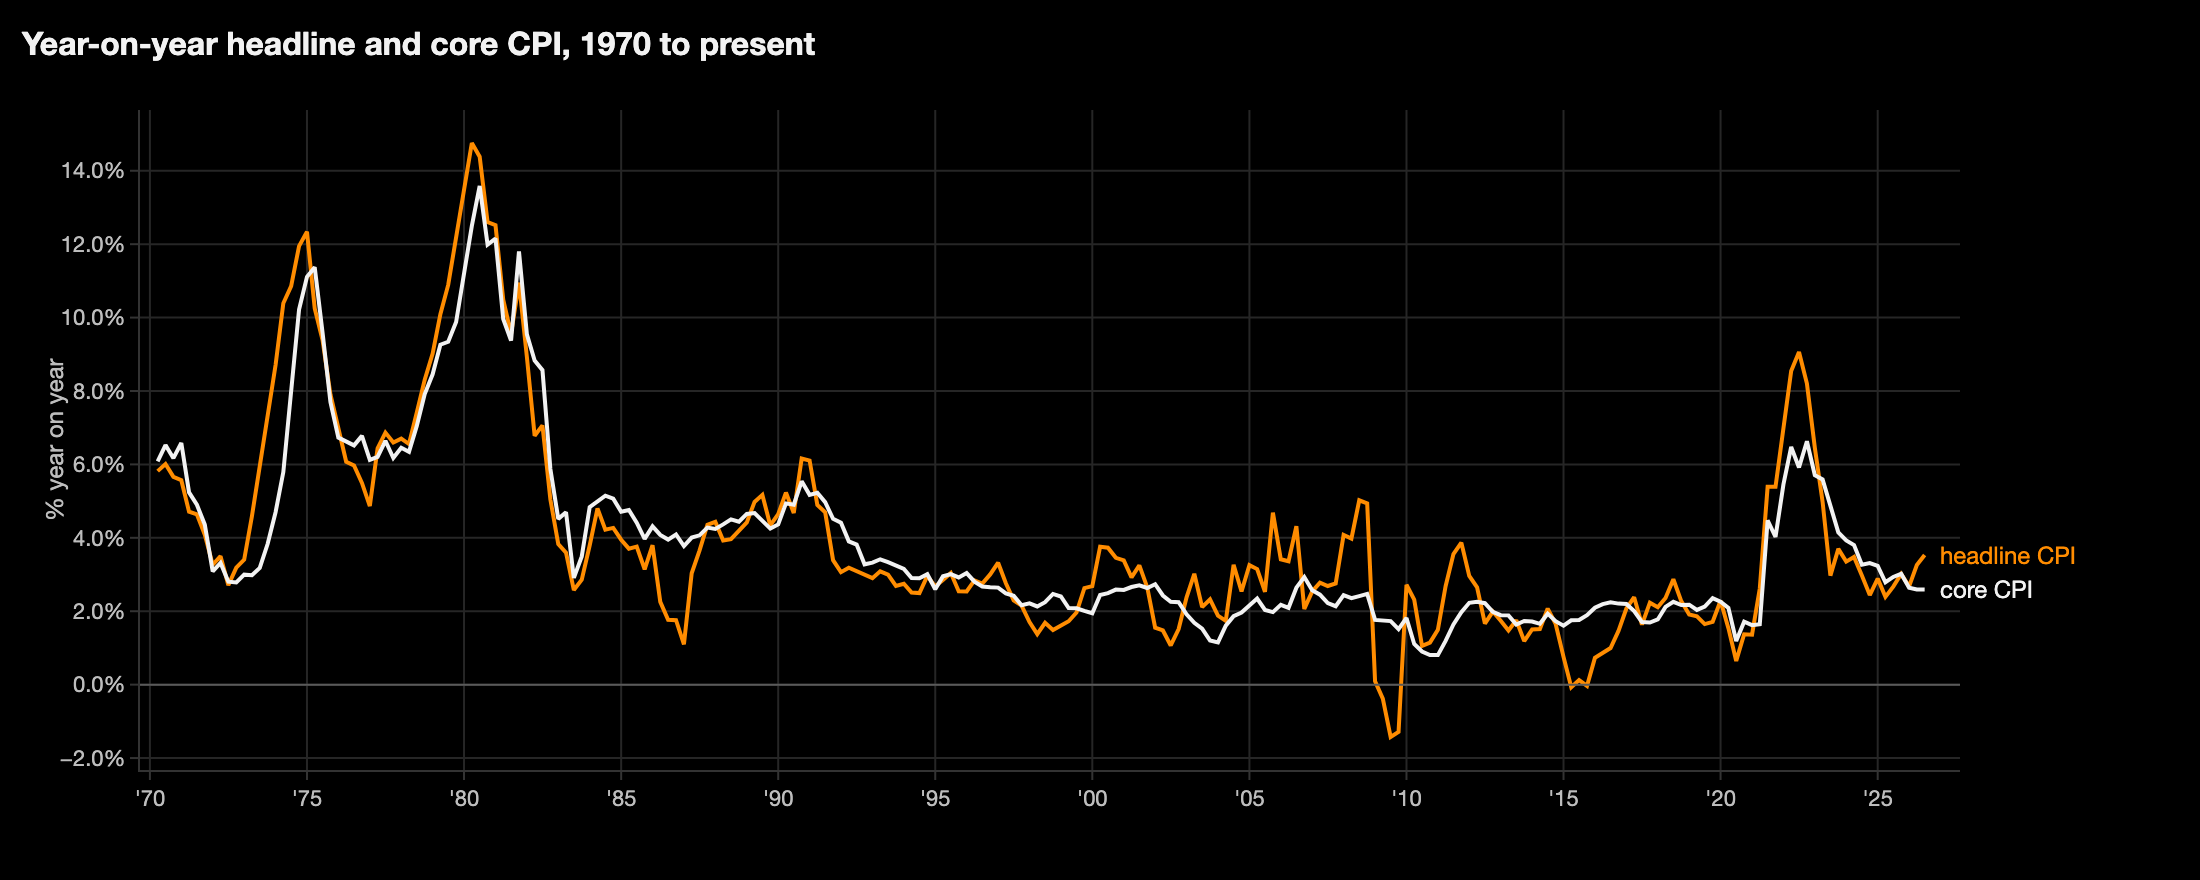

latest headline 3.53% (2026Q2), core 2.59% (2026Q2)


In [4]:
levels = dataset.macro_levels()
cpi_yoy = metrics.yoy_percent(levels["cpi"]).dropna()
core_yoy = metrics.yoy_percent(levels["core_cpi"]).dropna()
cpi_chart = pd.DataFrame({"headline CPI": cpi_yoy, "core CPI": core_yoy}).loc[pd.Period("1970Q1", freq="Q"):]

charts.line_chart(
    cpi_chart, title="Year-on-year headline and core CPI, 1970 to present", ylabel="% year on year", percent=1,
).show()

print(
    f"latest headline {cpi_yoy.iloc[-1]:.2f}% ({cpi_yoy.index[-1]}), "
    f"core {core_yoy.iloc[-1]:.2f}% ({core_yoy.index[-1]})"
)

While the *level* of inflation is important for economic analyses, we shall set it aside because asset price presumably already reflects the prevailing level of inflation - e.g., if inflation has been running at 6% for a while, a bond yielding 7% is not cheap, and yields have correspondingly adjusted. 

What moves prices instead is new information, i.e., the inflation *surprise*. The level chart will be useful for context, but the signal still has to be constructed.

## Part 2 — Constructing the surprise metric

Following AQR's methodology, we combine two measures of the news content of an inflation print. Let $\pi_t$ be the year-on-year CPI rate observed in quarter $t$, and $f_{t-4}$ the one-year-ahead CPI forecast made four quarters earlier.

$$\text{change}_t = \pi_t - \pi_{t-4}$$

$$\text{surprise}_t = \pi_t - f_{t-4}$$

> **Claude's explanation:**
>
> * The first is a random-walk model of expectations: last year's inflation was the forecast. The second uses what forecasters actually said. Neither is clean: the random walk is naive, and survey medians are stale and sometimes sparse — but they fail differently, so averaging them cancels some noise.
> * They are *not* averaged raw. Changes are mechanically larger than surprises, while asset returns are more sensitive to surprises, so a raw average would underweight the leg that carries the signal. Each leg is scaled to a common standard deviation first:
>
> $$\text{combined}_t = \tfrac{1}{2}\left(\text{change}_t + \lambda \cdot \text{surprise}_t\right),
> \qquad \lambda = \frac{\sigma(\text{change})}{\sigma(\text{surprise})}$$
>
> * Scaling to *change*'s standard deviation rather than to 1 keeps the metric in percentage points, the same units as inflation itself.
>
> * Two frequency choices (re AQR's methodology): everything is **quarterly**, and every window is an **overlapping year-on-year** one. Overlapping windows remove seasonality without seasonal adjustment and blunt publication lags. They also induce serial correlation in anything computed from them, which Part 3 has to deal with.

In [5]:
cpi_forecast, splice_notes = dataset.inflation_forecast_1y()
gdp_yoy = metrics.yoy_percent(levels["gdp"]).dropna()
gdp_forecast = dataset.growth_forecast_1y()

inflation = metrics.combine(
    metrics.change_metric(cpi_yoy),
    metrics.surprise_metric(cpi_yoy, cpi_forecast),
).loc[STUDY_START:]

growth = metrics.combine(
    metrics.change_metric(gdp_yoy),
    metrics.surprise_metric(gdp_yoy, gdp_forecast),
).loc[STUDY_START:]

print(f"scaling factor lambda            {inflation.attrs['surprise_scale']:.3f}")
print(f"sigma(change)                    {inflation['change'].std():.2f} pp")
print(f"sigma(surprise), unscaled        {inflation['surprise_raw'].std():.2f} pp")
print(f"sigma(combined)                  {inflation['combined'].std():.2f} pp")
print(f"corr(change, surprise)           {inflation['change'].corr(inflation['surprise_scaled']):.2f}")
print(f"quarters in sample               {int(inflation['combined'].notna().sum())}")

scaling factor lambda            1.082
sigma(change)                    2.24 pp
sigma(surprise), unscaled        2.06 pp
sigma(combined)                  2.12 pp
corr(change, surprise)           0.80
quarters in sample               218


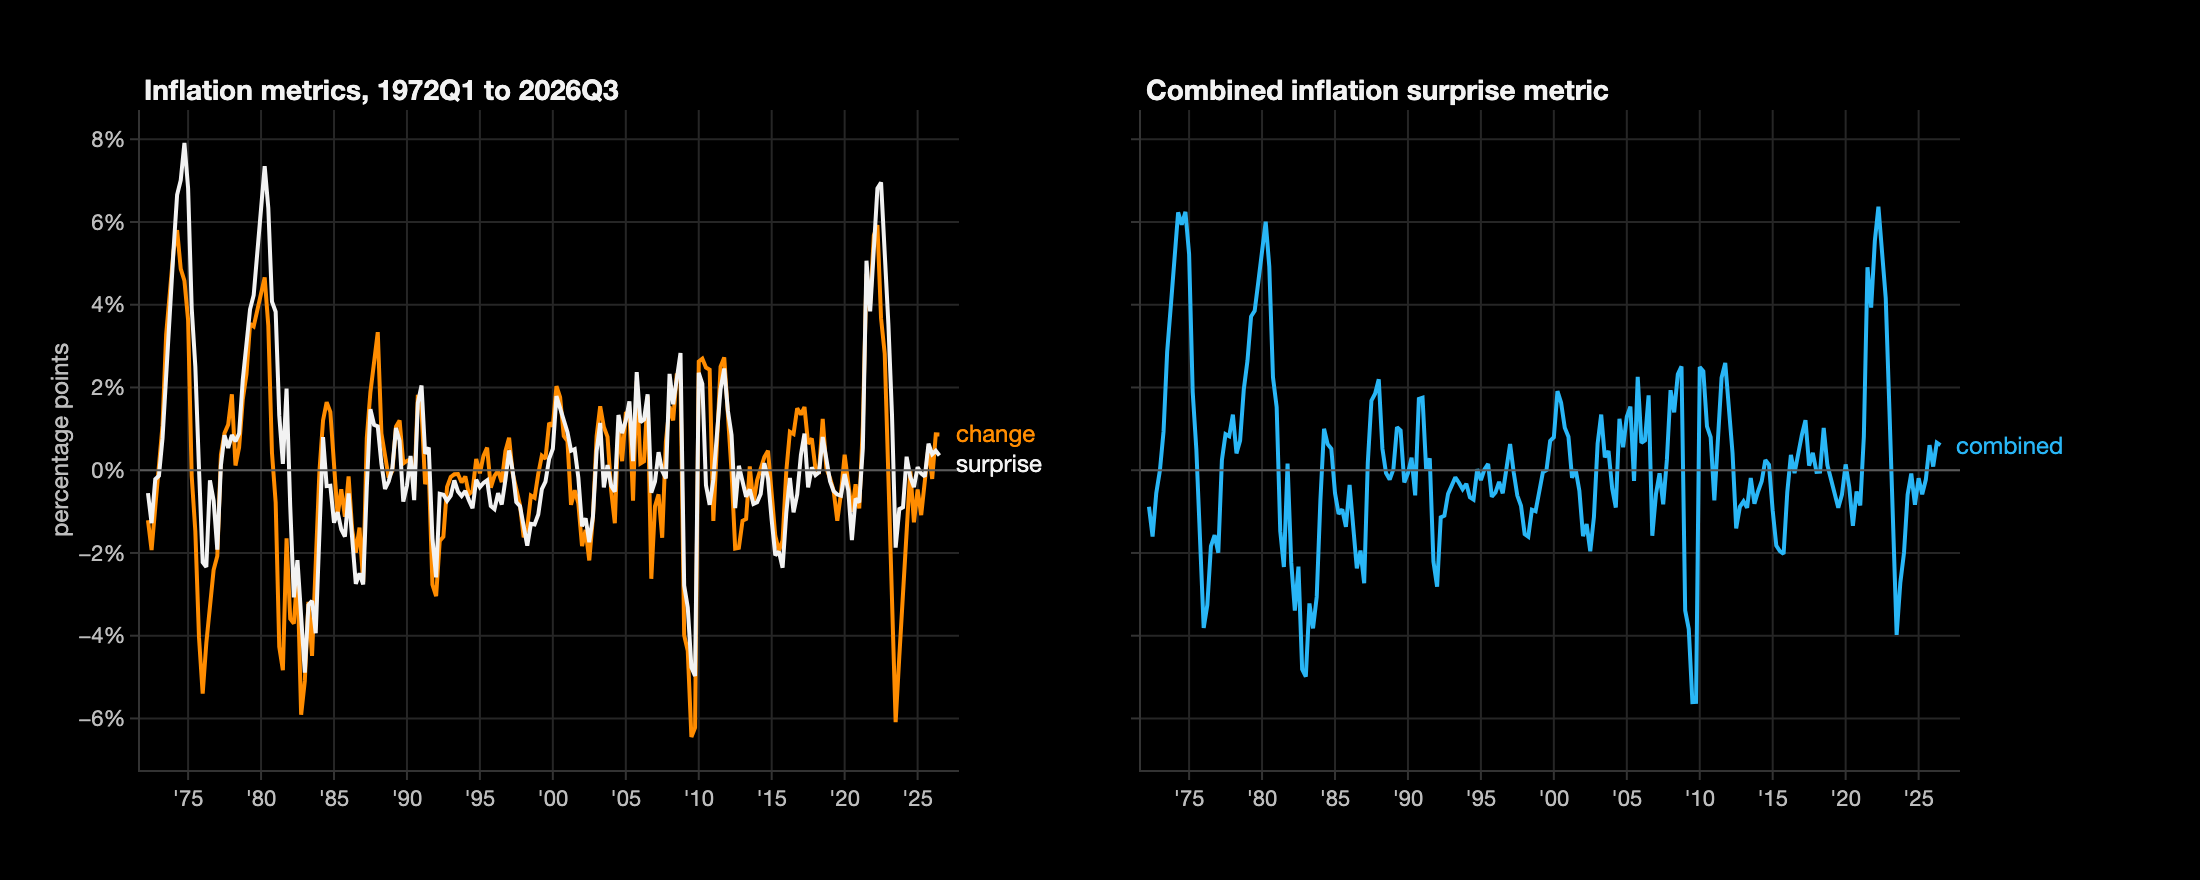

In [6]:
legs = inflation[["change", "surprise_scaled"]].rename(columns={"surprise_scaled": "surprise"})

fig = charts.subplots(
    titles=(f"Inflation metrics, {STUDY_START} to {inflation.index[-1]}", "Combined inflation surprise metric"),
    shared_y=True,
)
charts.line_chart(legs, fig=fig, row=1, col=1, ylabel="percentage points", percent=0)
charts.line_chart(inflation[["combined"]], fig=fig, row=1, col=2, percent=0)
fig.show()

### The one big assumption: the pre-1981 forecast

We have to backfill some data to make this study match the full period of AQR's study. I've used Claude to come up with a workaround solution. 

>
> From Claude:
>
>The Survey of Professional Forecasters (SPF) has only asked its panel about **CPI since 1981Q3**. A study beginning in 1972 therefore has no survey forecast for its first decade — which is precisely the decade that contains the Great Inflation and most of the upside surprises worth studying. 
>
>What we do have is the one SPF question that runs continuously from 1968Q4: the **GDP price index**. The fill is that forecast, plus the mean CPI-minus-deflator forecast wedge measured over the 181 quarters where both exist.
>
>This is an assumption, not a measurement, and it should be read as one. CPI and the deflator differ in weighting and in their treatment of shelter, and the wedge between them is not constant. The diagnostics below are the honest summary of how much that costs: the two forecasts correlate 0.96 over the overlap, and the wedge's own standard deviation (0.32pp) is about the same size as its mean (0.30pp) — so the level of the fill is reasonable and its quarter-to-quarter error is not negligible.
>

native_start         1981Q3
native_end           2026Q3
splice_start         1968Q4
wedge_pp             0.3
overlap_quarters     181
overlap_corr         0.964
wedge_std_pp         0.324


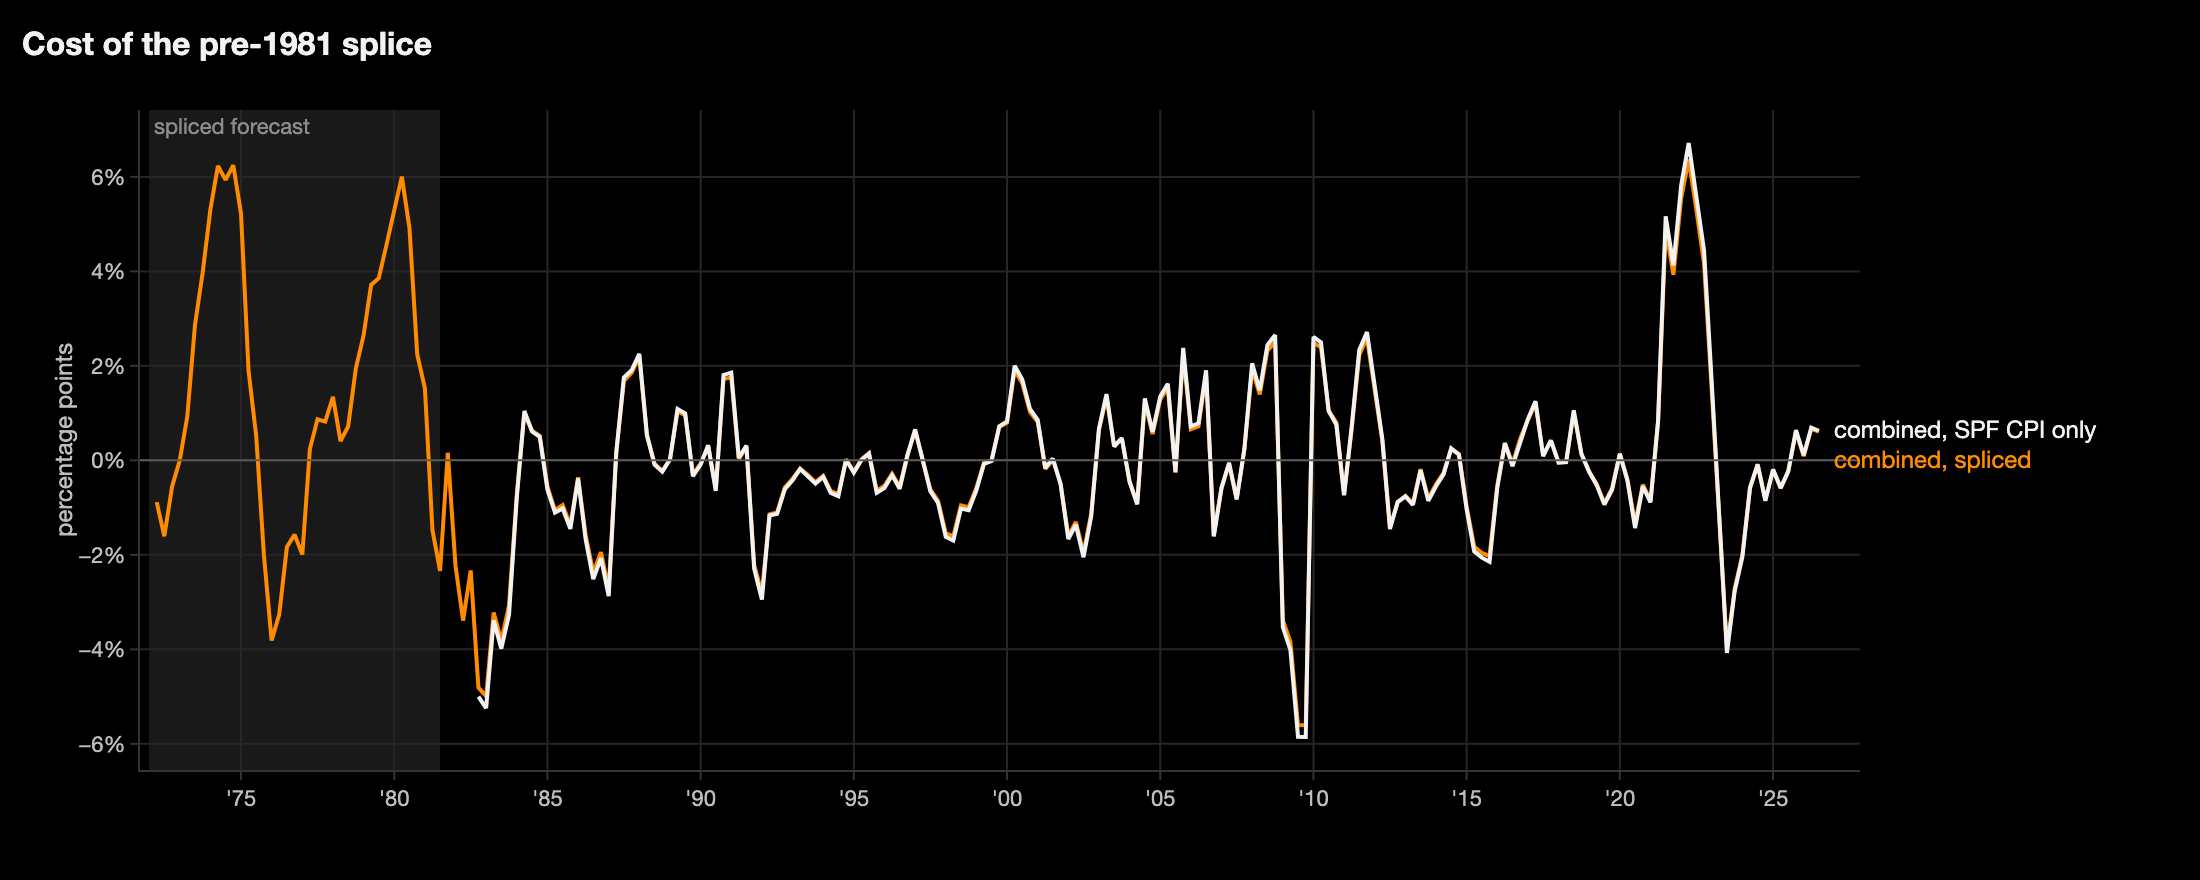

where both exist (176 quarters): correlation 0.9999, mean absolute difference 0.062 pp


In [7]:
for key, value in splice_notes.items():
    print(f"{key:20s} {value if not isinstance(value, float) else round(value, 3)}")

unspliced_forecast, _ = dataset.inflation_forecast_1y(splice_pre_1981=False)
unspliced = metrics.combine(
    metrics.change_metric(cpi_yoy),
    metrics.surprise_metric(cpi_yoy, unspliced_forecast),
).loc[STUDY_START:]

comparison = pd.DataFrame(
    {"combined, spliced": inflation["combined"], "combined, SPF CPI only": unspliced["combined"]}
)
fig = charts.line_chart(comparison, title="Cost of the pre-1981 splice", ylabel="percentage points", percent=0)
charts.shade_span(fig, "1972Q1", "1981Q2", note="spliced forecast")
fig.show()

overlap = comparison.dropna()
print(f"where both exist ({len(overlap)} quarters): correlation "
      f"{overlap.iloc[:, 0].corr(overlap.iloc[:, 1]):.4f}, "
      f"mean absolute difference {(overlap.iloc[:, 0] - overlap.iloc[:, 1]).abs().mean():.3f} pp")

>From Claude, continued:
>
>The shaded region is the spliced decade; to its right the two series are identical by construction (correlation 1.00), because the splice only ever fills the left-hand gap. The practical reading: if you distrust the splice, every number in this notebook still holds from 1981Q3 onward — you lose the 1970s, which hold more than half of the sample's upside-surprise quarters.

### Inflation environments

With the combined metric, we then classify each quarter by its z-score: an upside surprise above +1, a downside surprise below −1, stable in between.

One important caveat: it is computed over the full sample, so the classification **uses information from the future**. That is fine for the descriptive question here ("how did assets behave when inflation surprised?") but would **not** be fine for a trading rule.

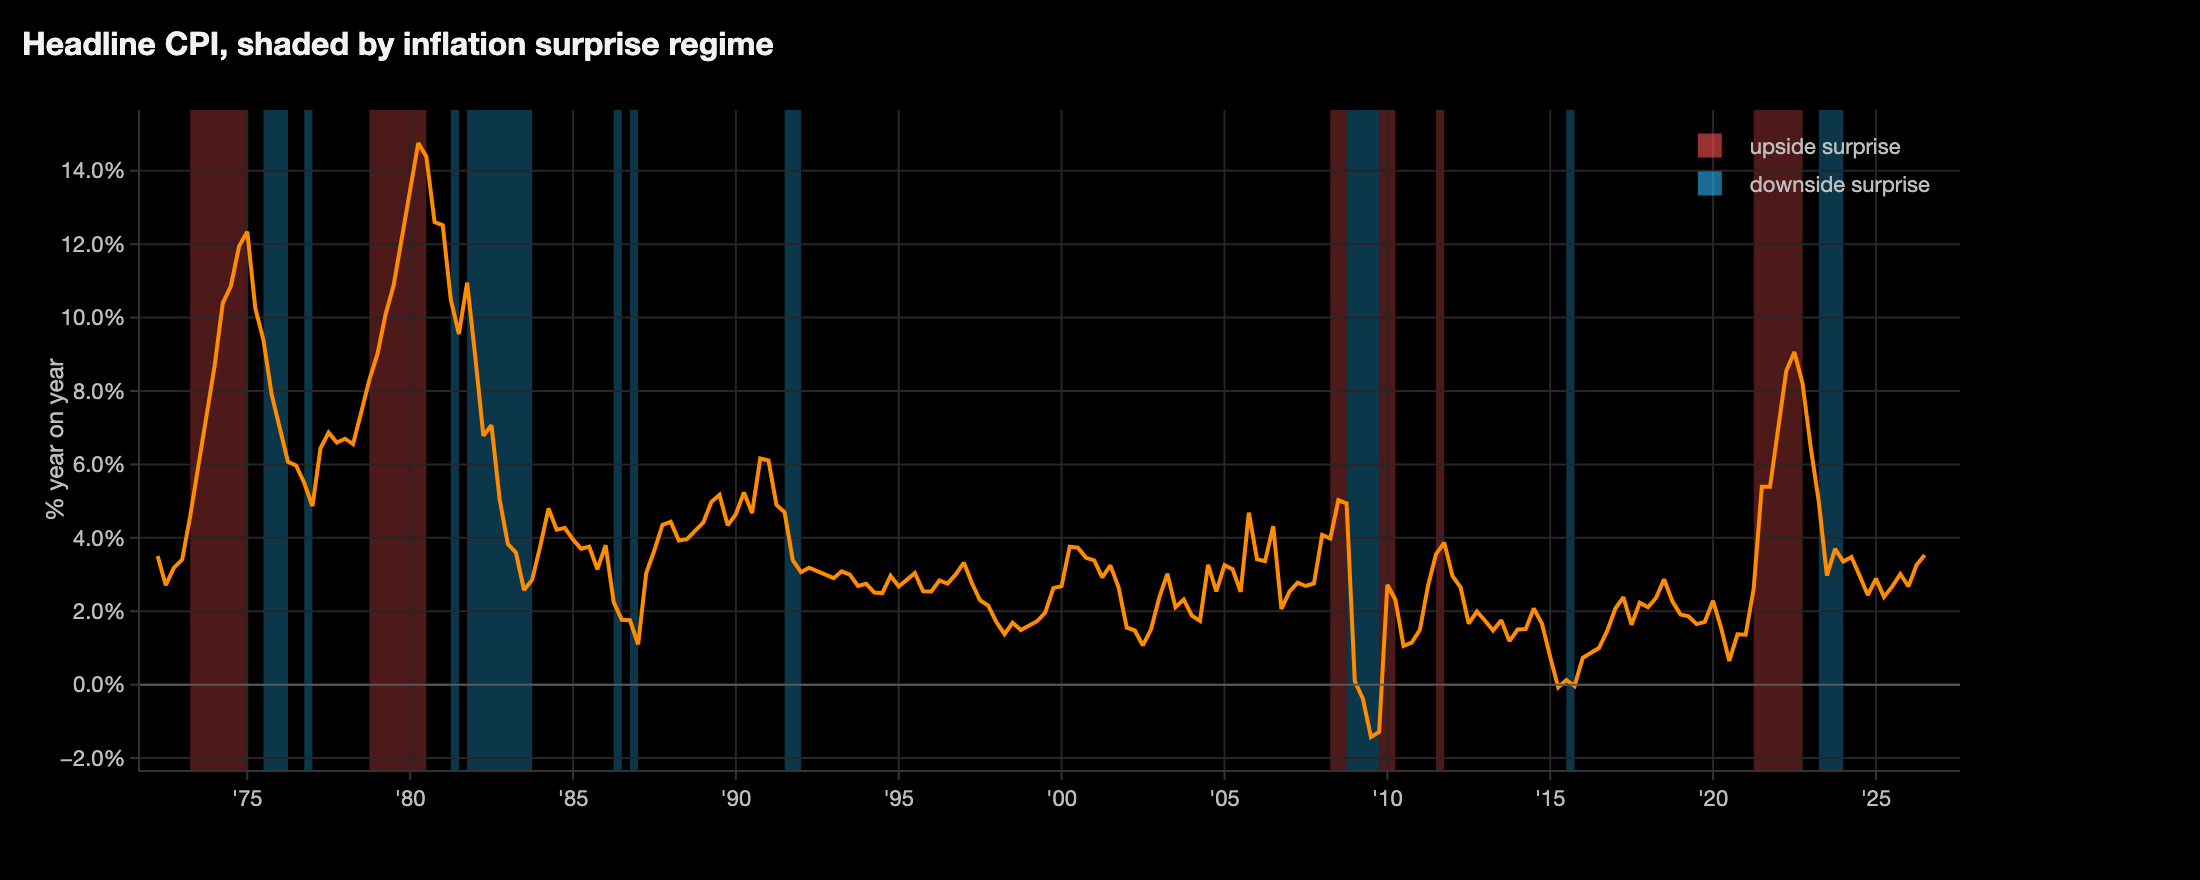

classification
upside       25
stable      168
downside     25 
218 quarters classified


In [8]:
classification = metrics.classify(inflation["combined"])
counts = classification.value_counts().reindex(charts.POLARITY_ORDER)

charts.regime_chart(
    cpi_yoy.loc[STUDY_START:].rename("headline CPI"), classification,
    title="Headline CPI, shaded by inflation surprise regime", ylabel="% year on year", percent=1,
).show()

print(counts.to_string(), f"\n{len(classification.dropna())} quarters classified")

### The growth control

Inflation and growth news are entangled — a supply shock raises one and lowers the other, a demand boom raises both. Without a control, an "inflation sensitivity" partly measures growth. So the same construction is applied to real GDP and used as the second factor in every partial correlation below.

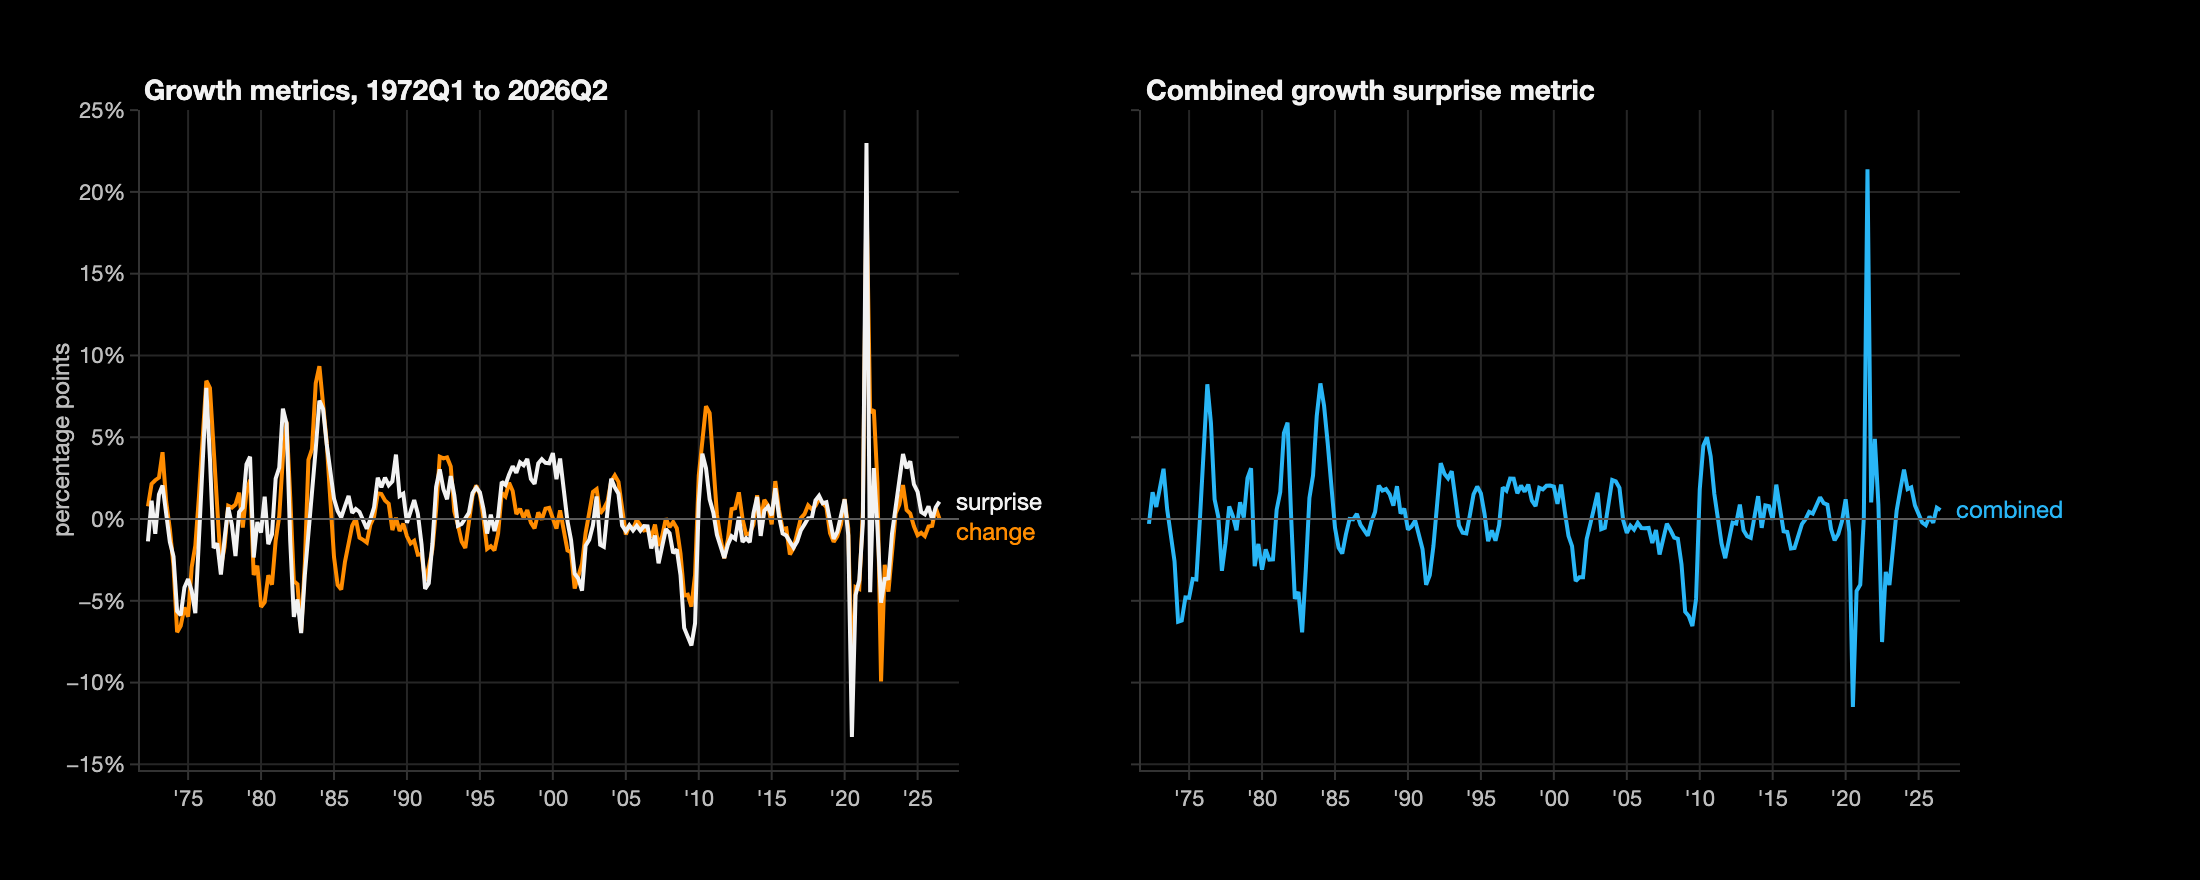

corr(inflation combined, growth combined) = -0.018


In [9]:
growth_legs = growth[["change", "surprise_scaled"]].rename(columns={"surprise_scaled": "surprise"})

fig = charts.subplots(
    titles=(f"Growth metrics, {STUDY_START} to {growth['combined'].last_valid_index()}", "Combined growth surprise metric"),
    shared_y=True,
)
charts.line_chart(growth_legs, fig=fig, row=1, col=1, ylabel="percentage points", percent=0)
charts.line_chart(growth[["combined"]], fig=fig, row=1, col=2, percent=0)
fig.show()

print(f"corr(inflation combined, growth combined) = "
      f"{inflation['combined'].corr(growth['combined']):.3f}")

The two metrics are close to uncorrelated over the full sample, which is what makes the two-factor partial correlation well behaved — and also why the growth control matters less than one might fear for the point estimates, while still raising their statistical confidence.

## Part 3 — Traditional assets

Equities, 10-year treasuries, and the 60/40 blend of the two, rebalanced monthly.

In [10]:
monthly, source_notes = dataset.monthly_asset_returns()
yoy_returns = dataset.quarterly_yoy_returns(monthly).loc[STUDY_START:]
quarterly_returns = dataset.quarterly_returns(monthly).loc[STUDY_START:]

TRADITIONAL = ["equities", "ust_10y", "sixty_forty"]
REAL = ["commodities", "gold", "precious_metals"]
if source_notes["reits_available"]:
    REAL.append("reits")
else:
    print(sources.NAREIT_INSTRUCTIONS)

print("commodity sourcing:", source_notes["commodities"])

commodity sourcing: {'aqr_end': Period('2025-05', 'M'), 'splice_ticker': 'GSG', 'overlap_months': 226, 'overlap_corr': 0.8702417912074976, 'splice_start': Period('2025-06', 'M'), 'splice_months': 15}


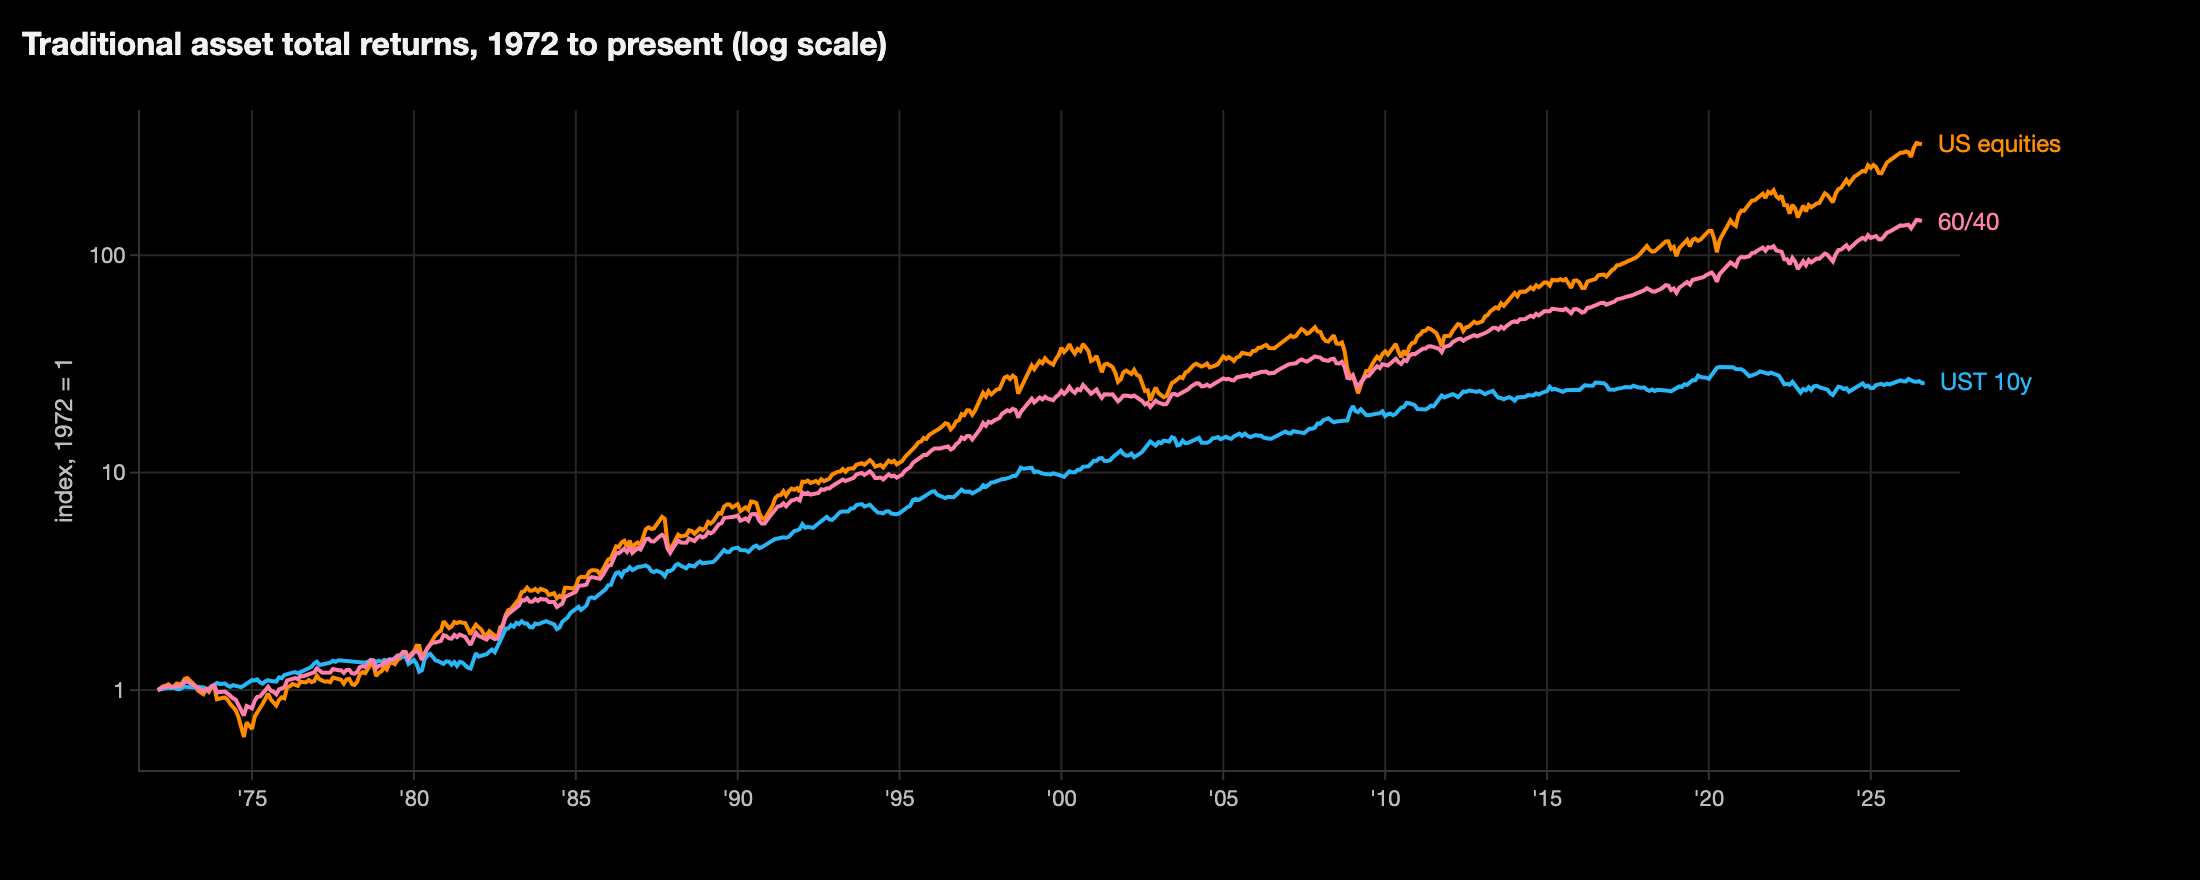

In [11]:
charts.wealth_chart(monthly[TRADITIONAL], title="Traditional asset total returns, 1972 to present (log scale)").show()

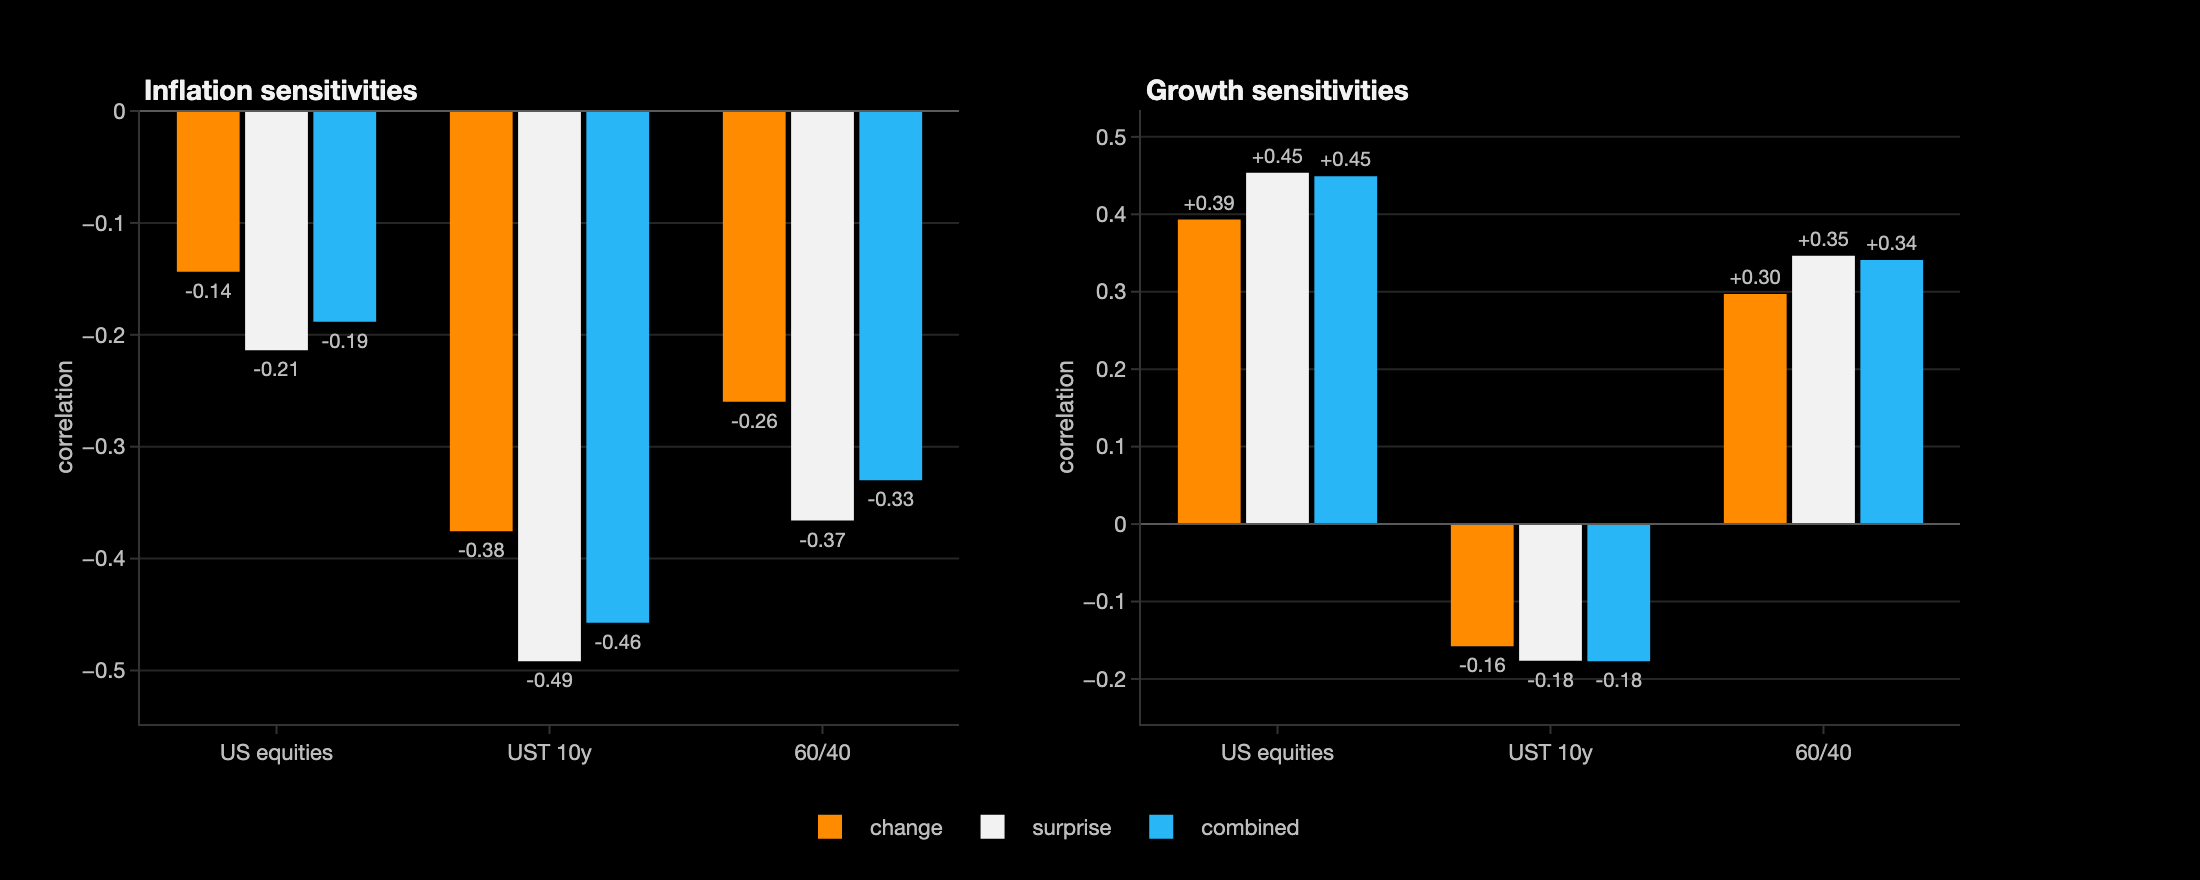

,infl_change,infl_surprise,infl_combined,infl_partial,growth_combined,growth_partial,nobs
asset,,,,,,,
equities,-0.144,-0.214,-0.188,-0.202,0.449,0.454,218
ust_10y,-0.376,-0.492,-0.457,-0.468,-0.177,-0.208,218
sixty_forty,-0.260,-0.366,-0.330,-0.345,0.341,0.355,218


In [12]:
sensitivities = metrics.sensitivity_table(yoy_returns[TRADITIONAL + REAL], inflation, growth)

fig = charts.subplots(titles=("Inflation sensitivities", "Growth sensitivities"))
charts.sensitivity_bars(sensitivities, factor="infl", order=TRADITIONAL, fig=fig, row=1, col=1, show_legend=False)
charts.sensitivity_bars(sensitivities, factor="growth", order=TRADITIONAL, fig=fig, row=1, col=2)
fig.show()

sensitivities.loc[TRADITIONAL, [
    "infl_change", "infl_surprise", "infl_combined", "infl_partial",
    "growth_combined", "growth_partial", "nobs",
]].round(3)

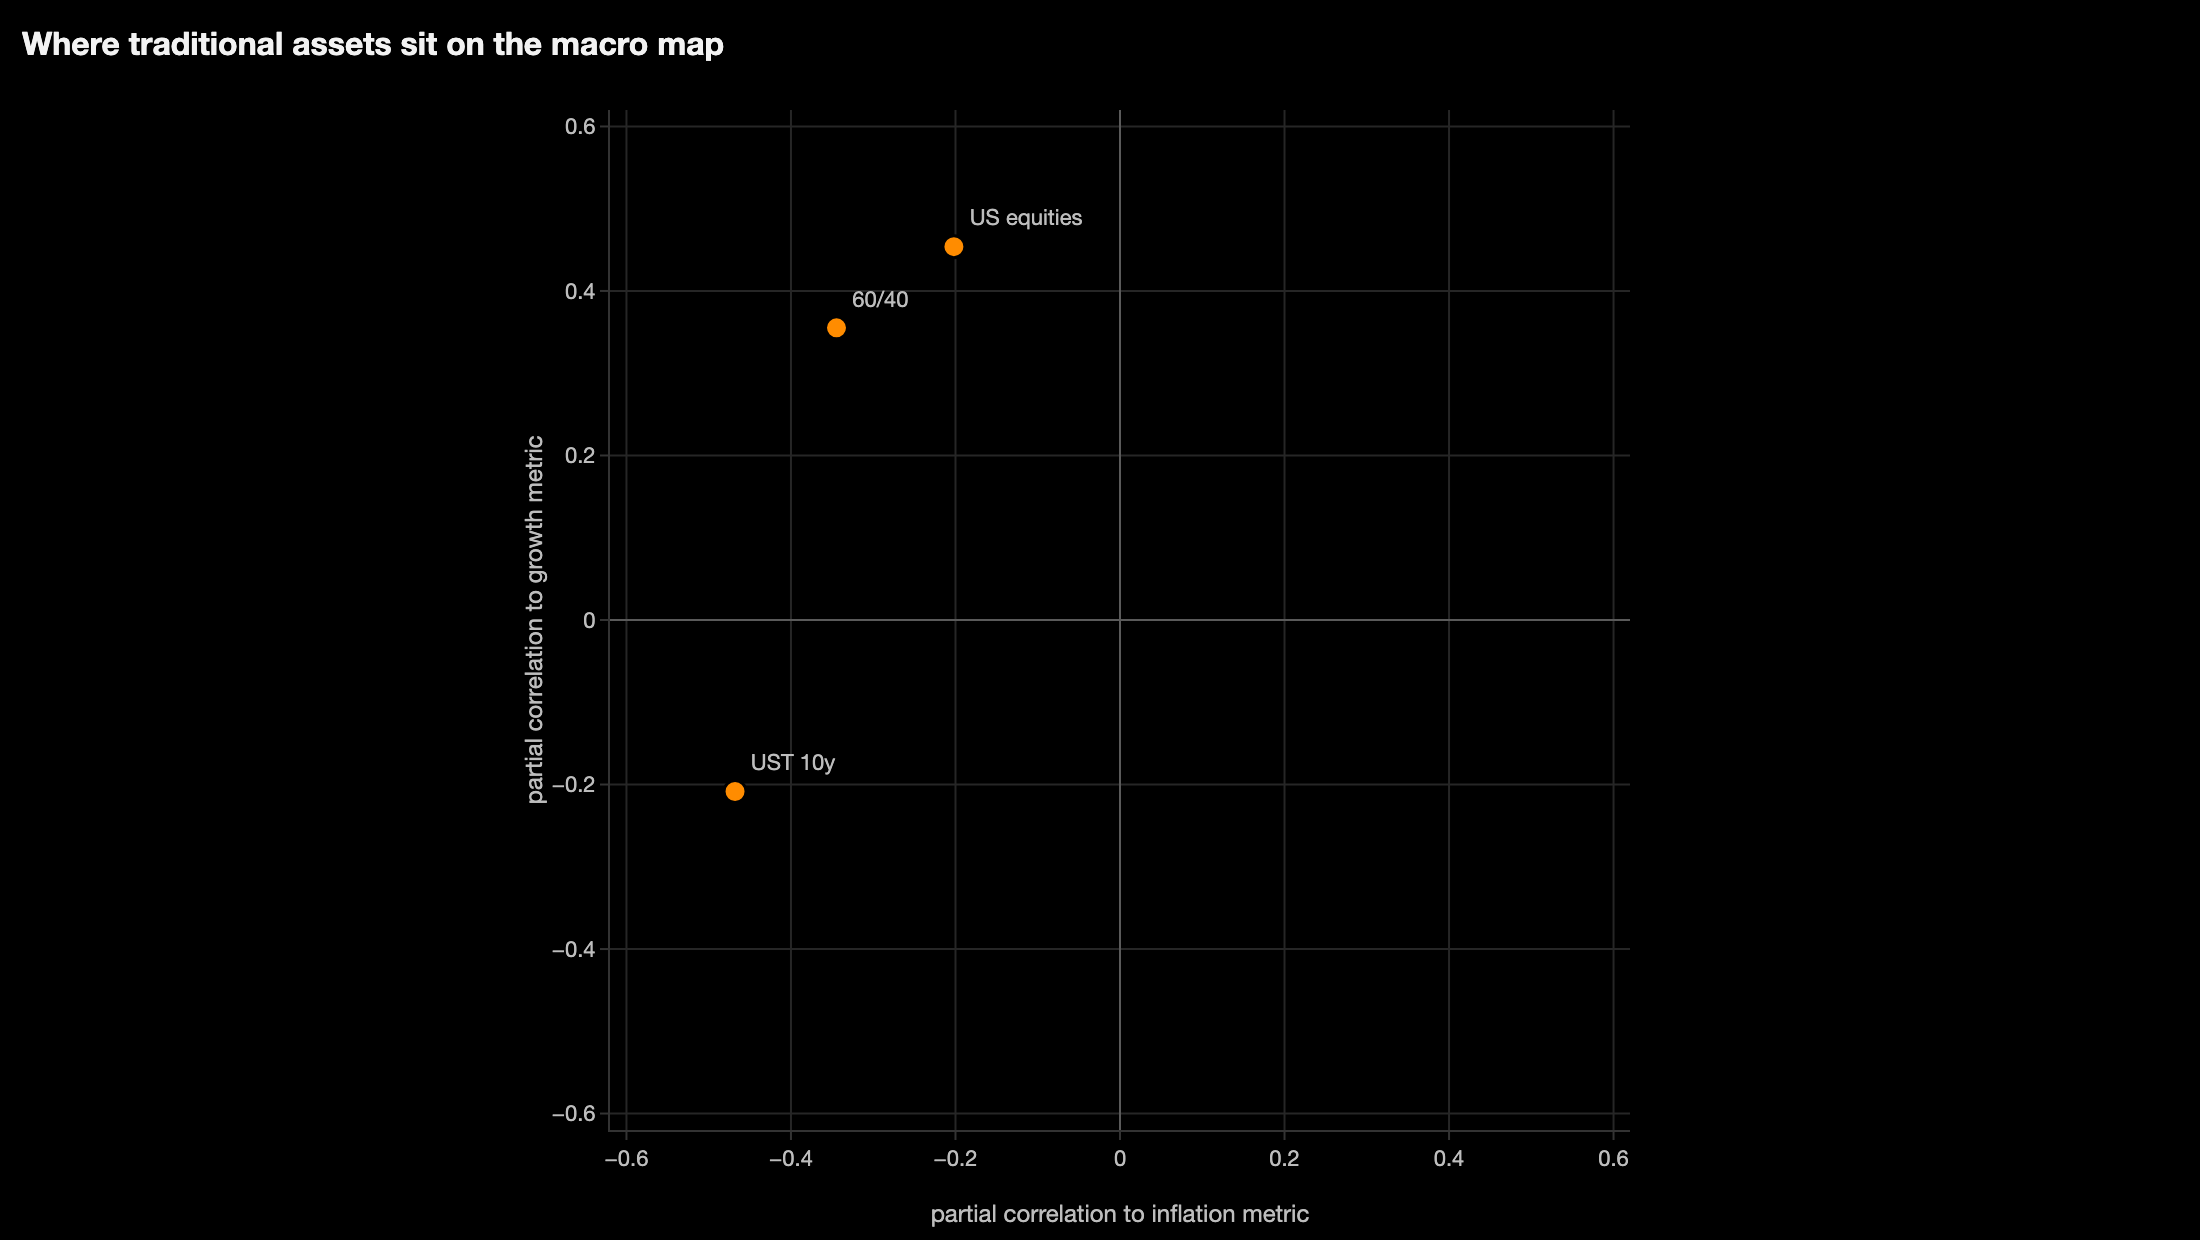

In [13]:
charts.sensitivity_scatter(
    sensitivities.loc[TRADITIONAL], title="Where traditional assets sit on the macro map", limit=0.62,
).show()

This is the study's central takeaway. 

Interpretation:
* **Vertical axis: growth.** Equities and treasuries sit on opposite sides of zero. This is the diversification benefit that investors own - but it applies only along the growth axis.
* **Horizontal axis: inflation.** Both asset classes sit on the *same* side, with treasuries further out than equities (presumably because we're using 10Y treasuries - which are quite long-dated). Importantly, there is no diversification along this axis at all. The 60/40 lands between them on both, which highlights the core problem that it has unhedged inflation exposure.

### Significance, given overlapping windows (from Claude)

The correlations above are computed on overlapping year-on-year windows sampled quarterly, so consecutive observations share three quarters of data. Their residuals are strongly autocorrelated, and a naive standard error is therefore far too small — a real risk of reading noise as signal. The t-statistics below are Newey-West corrected with three lags, the autocorrelation the overlap mechanically induces.

In [14]:
inference = pd.DataFrame(
    {
        asset: metrics.hac_significance(
            yoy_returns[asset], inflation["combined"], growth["combined"]
        )
        for asset in TRADITIONAL + REAL
    }
).T
inference["significant at 5%"] = inference["pvalue"] < 0.05
inference.round({"beta": 3, "tstat": 2, "pvalue": 4})

,beta,tstat,pvalue,nobs,significant at 5%
equities,-0.180,-1.83,0.0672,218.0,False
ust_10y,-0.461,-4.53,0.0000,218.0,True
sixty_forty,-0.324,-2.90,0.0037,218.0,True
commodities,0.634,5.44,0.0000,218.0,True
gold,0.479,3.17,0.0015,218.0,True
precious_metals,0.478,2.97,0.0030,218.0,True
reits,-0.018,-0.15,0.8823,214.0,False


As of 19-Sep-2026:

The treasury, commodity and metals sensitivities survive the correction comfortably. The equity inflation sensitivity does not — at around −1.8 it sits just outside conventional significance.

Before reading that as "equities are unaffected", it is worth asking whether the *horizon* is doing the work rather than the data. The next section tests exactly that, and the answer qualifies this one.

### Does the horizon drive the result? [Claude]

The metric measures twelve months of inflation news, so it has to be compared against a return measured over a comparable window — which is why every figure above uses overlapping year-on-year returns. The cost is that, over 218 quarterly observations of a 12-month window (as of 20-Sep-2026), there is only about **54 independent years** of information.

So the same test, at three horizons. Note the third is the weakest of the three by construction — the metric is quarterly, so using it against monthly returns means holding each quarter's value flat across three months, which repeats information rather than adding it. The Newey-West lags absorb some of that. Read it as indicative; the non-overlapping quarterly column is the clean comparison.

In [15]:
# The same sensitivity test at three return horizons.
monthly_window = monthly.loc[pd.Period("1972-01", freq="M"):]
quarter_of = pd.PeriodIndex(monthly_window.index, freq="Q")

HORIZONS = {
    "YoY overlap (quarterly)": (yoy_returns, inflation["combined"], growth["combined"], 3),
    "quarterly, non-overlapping": (quarterly_returns, inflation["combined"], growth["combined"], 1),
    "monthly (metric held flat)": (
        monthly_window,
        inflation["combined"].reindex(quarter_of).set_axis(monthly_window.index),
        growth["combined"].reindex(quarter_of).set_axis(monthly_window.index),
        3,
    ),
}

rows = []
for label, (returns, infl_leg, growth_leg, lags) in HORIZONS.items():
    for asset in TRADITIONAL + REAL:
        hac = metrics.hac_significance(returns[asset], infl_leg, growth_leg, lags=lags)
        rows.append({
            "horizon": label,
            "asset": asset,
            "correlation": returns[asset].corr(infl_leg),
            "partial": metrics.partial_correlation(returns[asset], infl_leg, growth_leg),
            "tstat": hac["tstat"],
            "nobs": hac["nobs"],
        })

robustness = pd.DataFrame(rows)
order = TRADITIONAL + REAL
columns = list(HORIZONS)

def table(value):
    return (
        robustness.pivot(index="asset", columns="horizon", values=value)
        .reindex(order)
        .reindex(columns=columns)
    )

print("Correlation to the combined inflation metric\n")
print(table("correlation").round(3).to_string())
print("\nNewey-West t-statistic, growth controlled\n")
print(table("tstat").round(2).to_string())
print("\nobservations per horizon:",
      robustness.groupby("horizon")["nobs"].max().reindex(columns).to_dict())

Correlation to the combined inflation metric

horizon          YoY overlap (quarterly)  quarterly, non-overlapping  monthly (metric held flat)
asset                                                                                           
equities                          -0.188                      -0.202                      -0.126
ust_10y                           -0.457                      -0.214                      -0.140
sixty_forty                       -0.330                      -0.261                      -0.161
commodities                        0.631                       0.200                       0.129
gold                               0.483                       0.234                       0.135
precious_metals                    0.481                       0.212                       0.119
reits                             -0.024                      -0.144                      -0.080

Newey-West t-statistic, growth controlled

horizon          YoY overlap (quarter

Two things takeaways: [Claude]
* **The signs never move; the magnitudes shrink as the horizon shortens.** As of 19/Sep/26 - commodities go from +0.63 to +0.20 to +0.13. This mechanic is rather than interesting — a slow twelve-month news measure explains far less of one month's return than of a year's. It does not mean the year-on-year figures are inflated: they are the correlation at the horizon the signal actually operates on, which is the horizon the question is about.
* **Significance moves the other way, and that qualifies the result above.** Shortening the horizon loses correlation but gains observations faster than it loses them, so the t-statistics *rise*: equities go from −1.8 at the year-on-year horizon to roughly −2.5 quarterly and −2.8 monthly. So the equity finding is not "insignificant" — it is significant at the shorter horizons, which is precisely the specification with the least power to resolve a small effect.

The statement that survives all three: equities' inflation sensitivity is **real but small** — too small for 55 independent years to resolve, large enough for 655 months to. Bonds, commodities and gold clear the bar at every horizon, which is why they carry the conclusions.

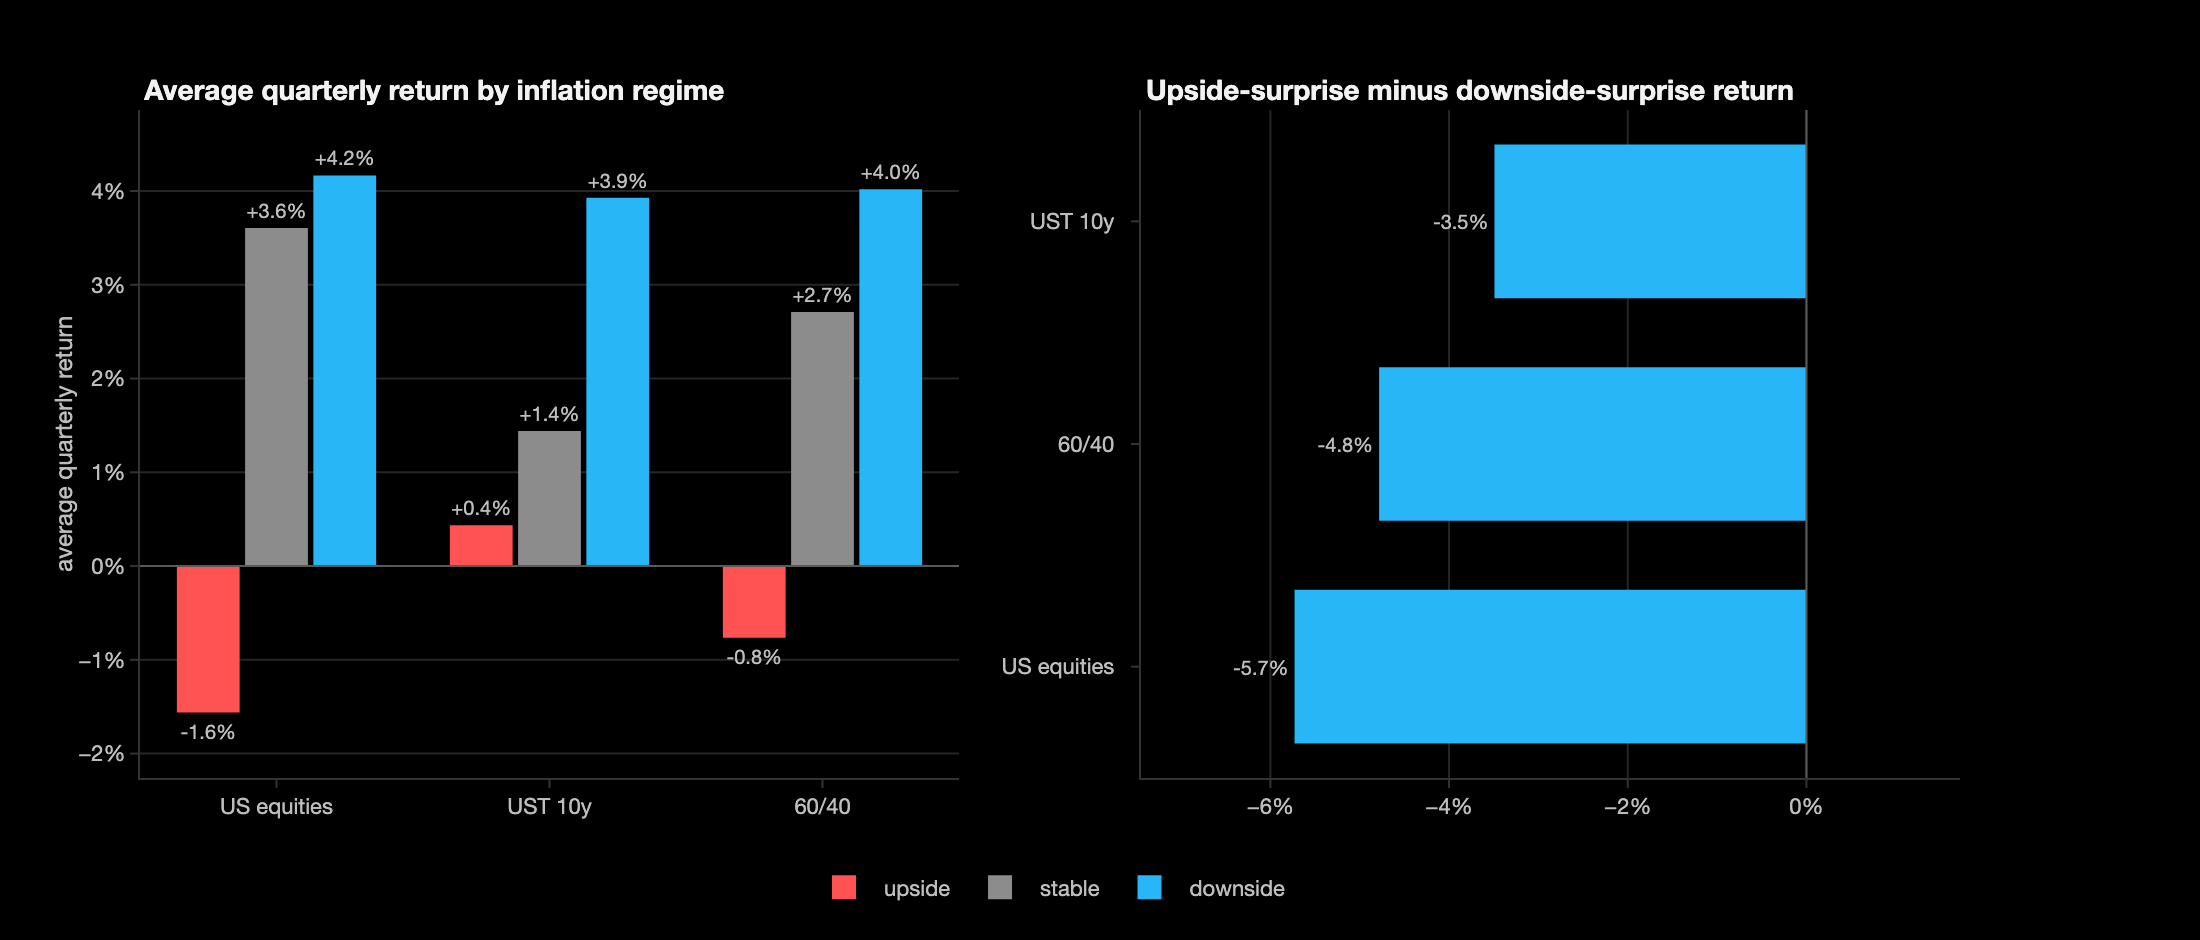

classification,upside,stable,downside
equities,-1.56,3.61,4.17
ust_10y,0.44,1.44,3.93
sixty_forty,-0.76,2.71,4.02
commodities,6.07,2.36,0.36
gold,10.94,3.09,0.64
precious_metals,10.87,3.20,0.73
reits,0.26,3.37,3.66


In [16]:
regime_averages = (
    quarterly_returns[TRADITIONAL + REAL]
    .groupby(classification)
    .mean()
    .T.reindex(columns=charts.POLARITY_ORDER)
)

fig = charts.subplots(
    titles=("Average quarterly return by inflation regime", "Upside-surprise minus downside-surprise return"),
    height=470,
)
charts.tritile_bars(regime_averages.loc[TRADITIONAL], fig=fig, row=1, col=1)
charts.upside_minus_downside(regime_averages.loc[TRADITIONAL], fig=fig, row=1, col=2)
fig.show()

regime_averages.round(2)

[Claude]

Every traditional sleeve earns less when inflation surprises to the upside than when it surprises to the downside, and the gap is wide — several percent *per quarter*. Note that equities are worst in the upside column but also strong in the downside column, the "frown" AQR describes: equities dislike inflation news in either direction less symmetrically than bonds do, because falling inflation in this sample usually arrived alongside a growth shock.

## Part 4 — Real assets

The same treatment for the assets that are supposed to help: broad commodities, gold, precious metals, and REITs.

REITs are the FTSE Nareit All Equity REITs total return index, read from NAREIT's own historical workbook. REITS are  the one series here that cannot be fetched automatically — reit.com blocks scripted requests — so it is read from a file in `manual/`, and the sleeve is dropped, with a note, if that file is absent.

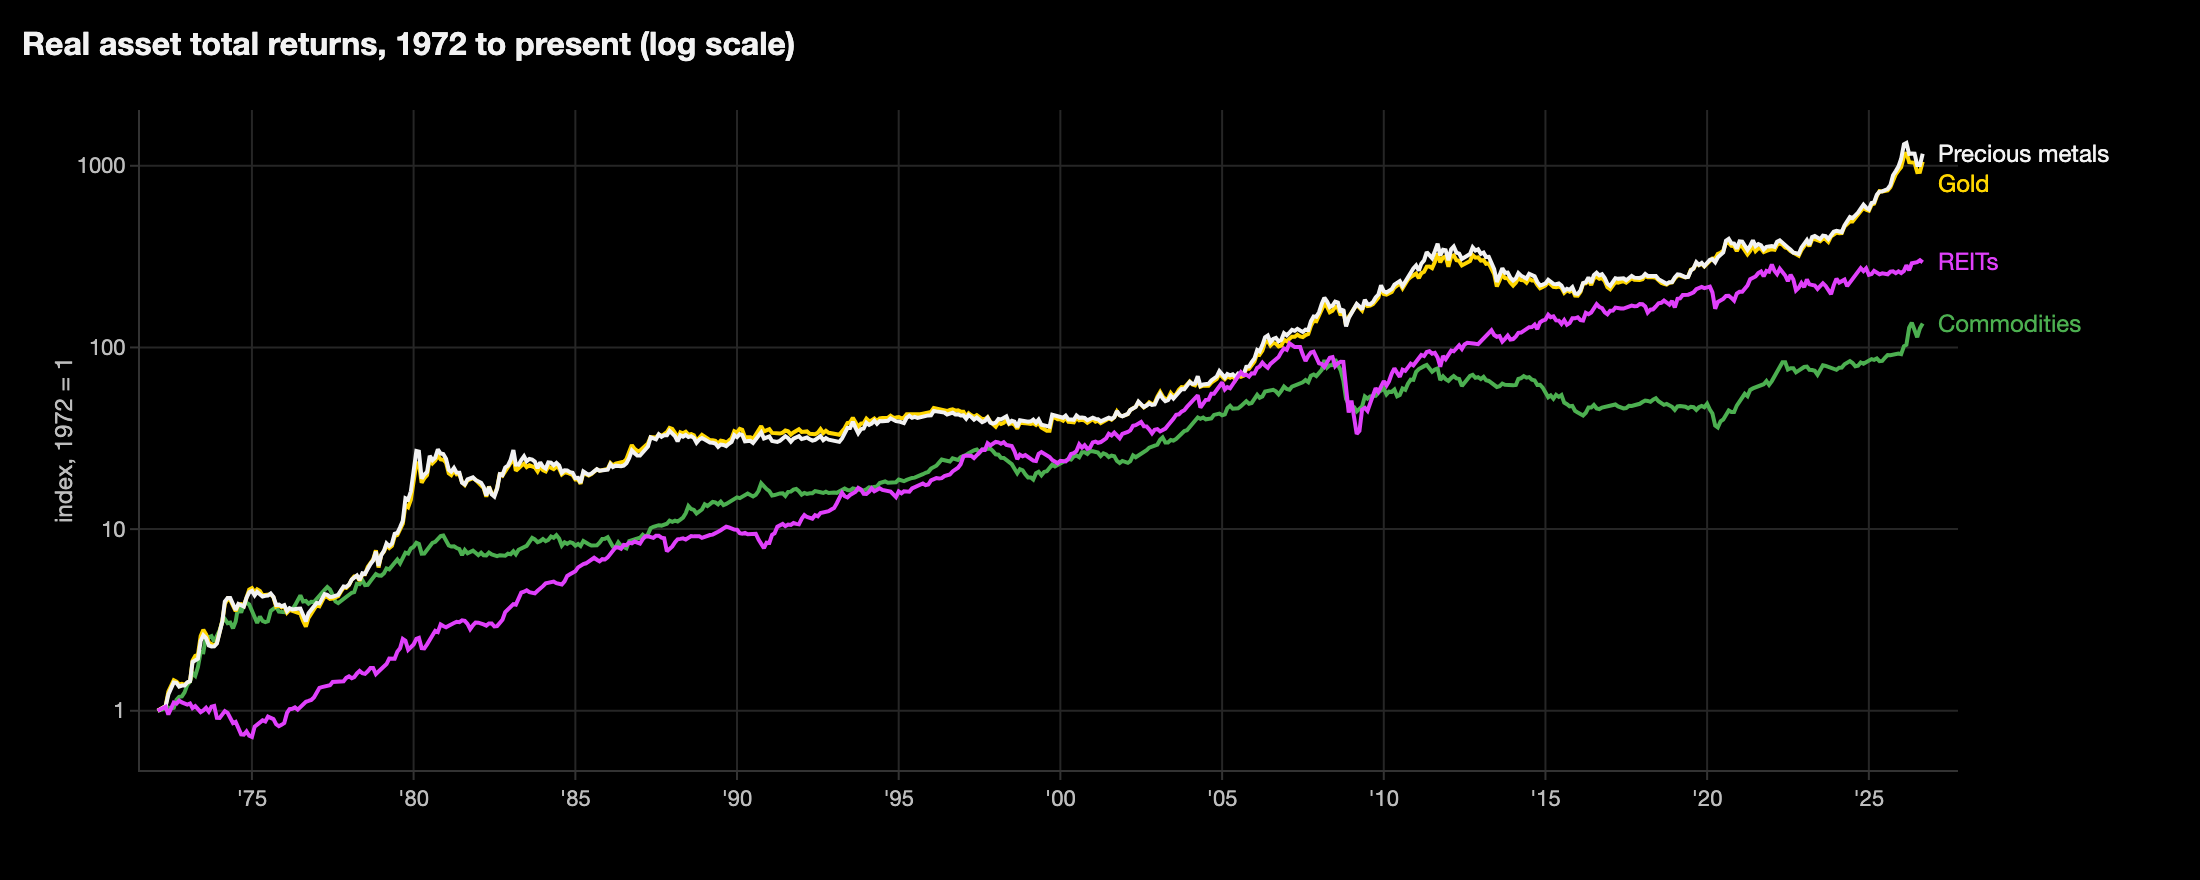

In [17]:
charts.wealth_chart(monthly[REAL], title="Real asset total returns, 1972 to present (log scale)").show()

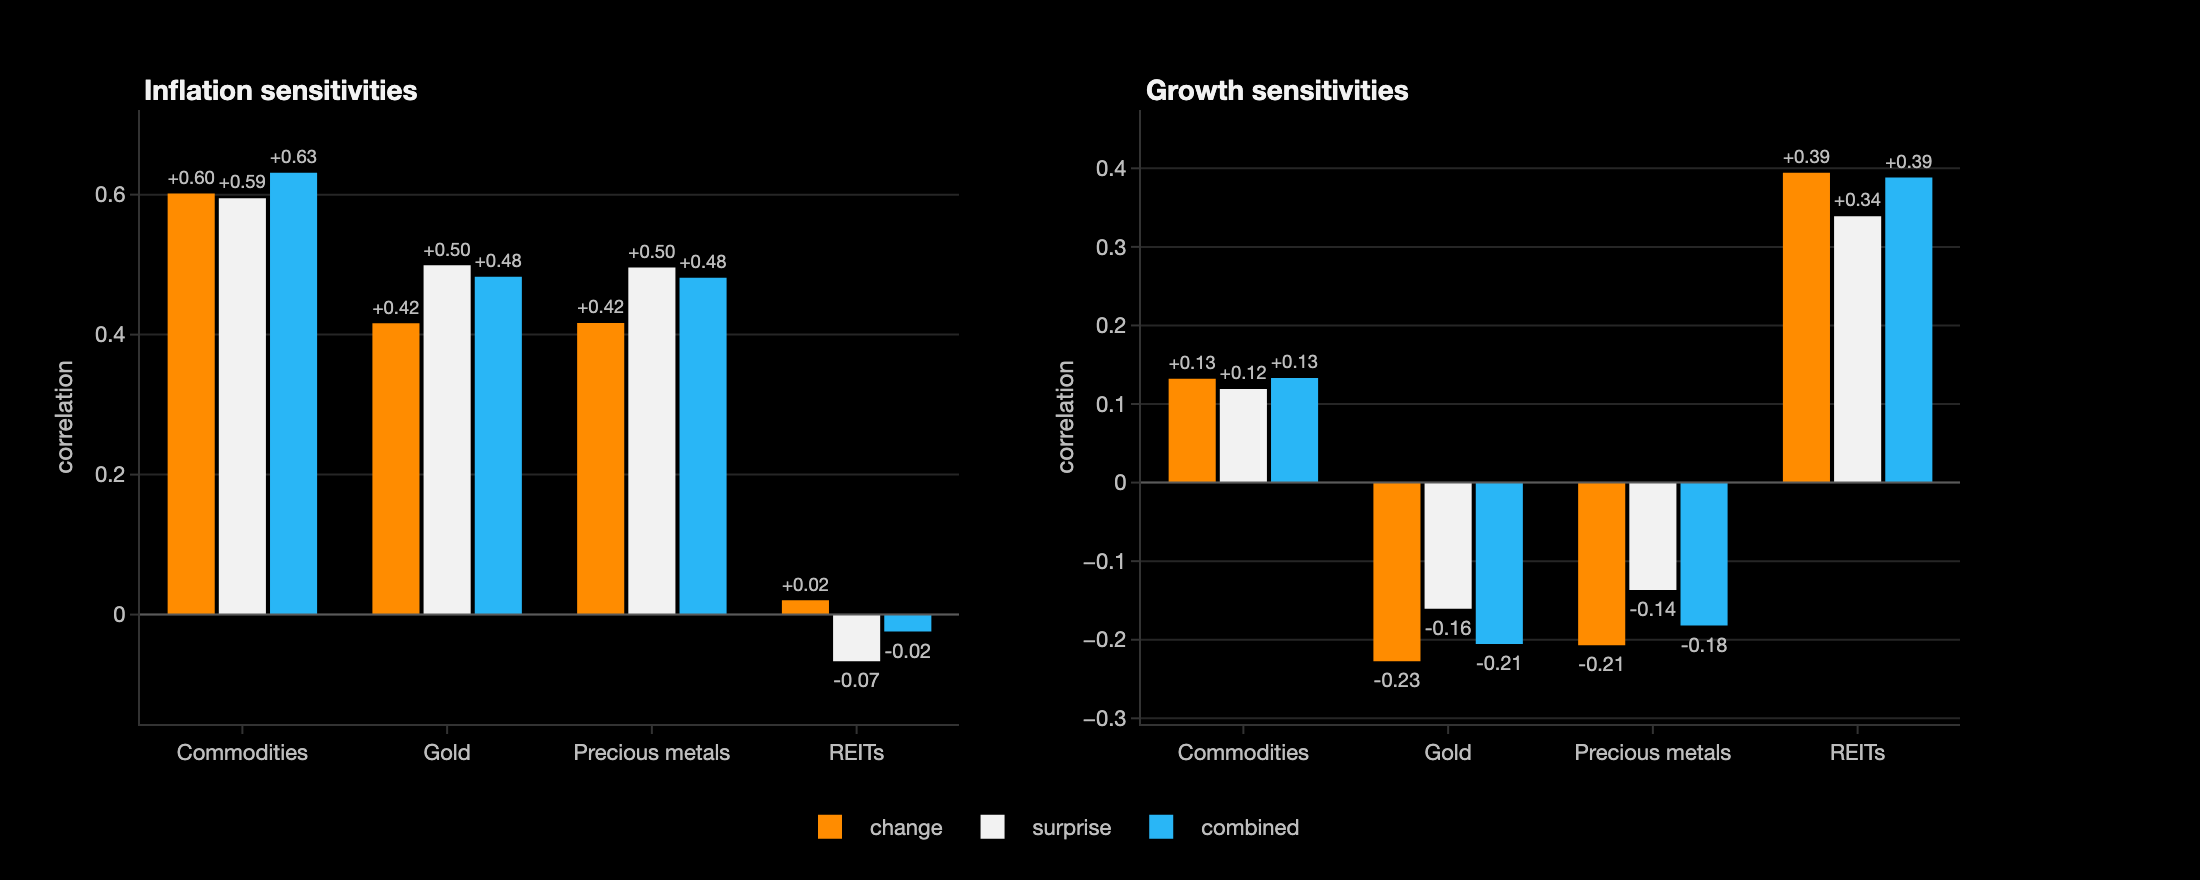

,infl_change,infl_surprise,infl_combined,infl_partial,growth_combined,growth_partial,nobs
asset,,,,,,,
commodities,0.602,0.595,0.631,0.640,0.133,0.186,218
gold,0.416,0.499,0.483,0.490,-0.205,-0.225,218
precious_metals,0.416,0.496,0.481,0.486,-0.182,-0.198,218
reits,0.020,-0.067,-0.024,-0.020,0.388,0.388,214


In [18]:
fig = charts.subplots(titles=("Inflation sensitivities", "Growth sensitivities"))
charts.sensitivity_bars(sensitivities, factor="infl", order=REAL, fig=fig, row=1, col=1, show_legend=False)
charts.sensitivity_bars(sensitivities, factor="growth", order=REAL, fig=fig, row=1, col=2)
fig.show()

sensitivities.loc[REAL, [
    "infl_change", "infl_surprise", "infl_combined", "infl_partial",
    "growth_combined", "growth_partial", "nobs",
]].round(3)

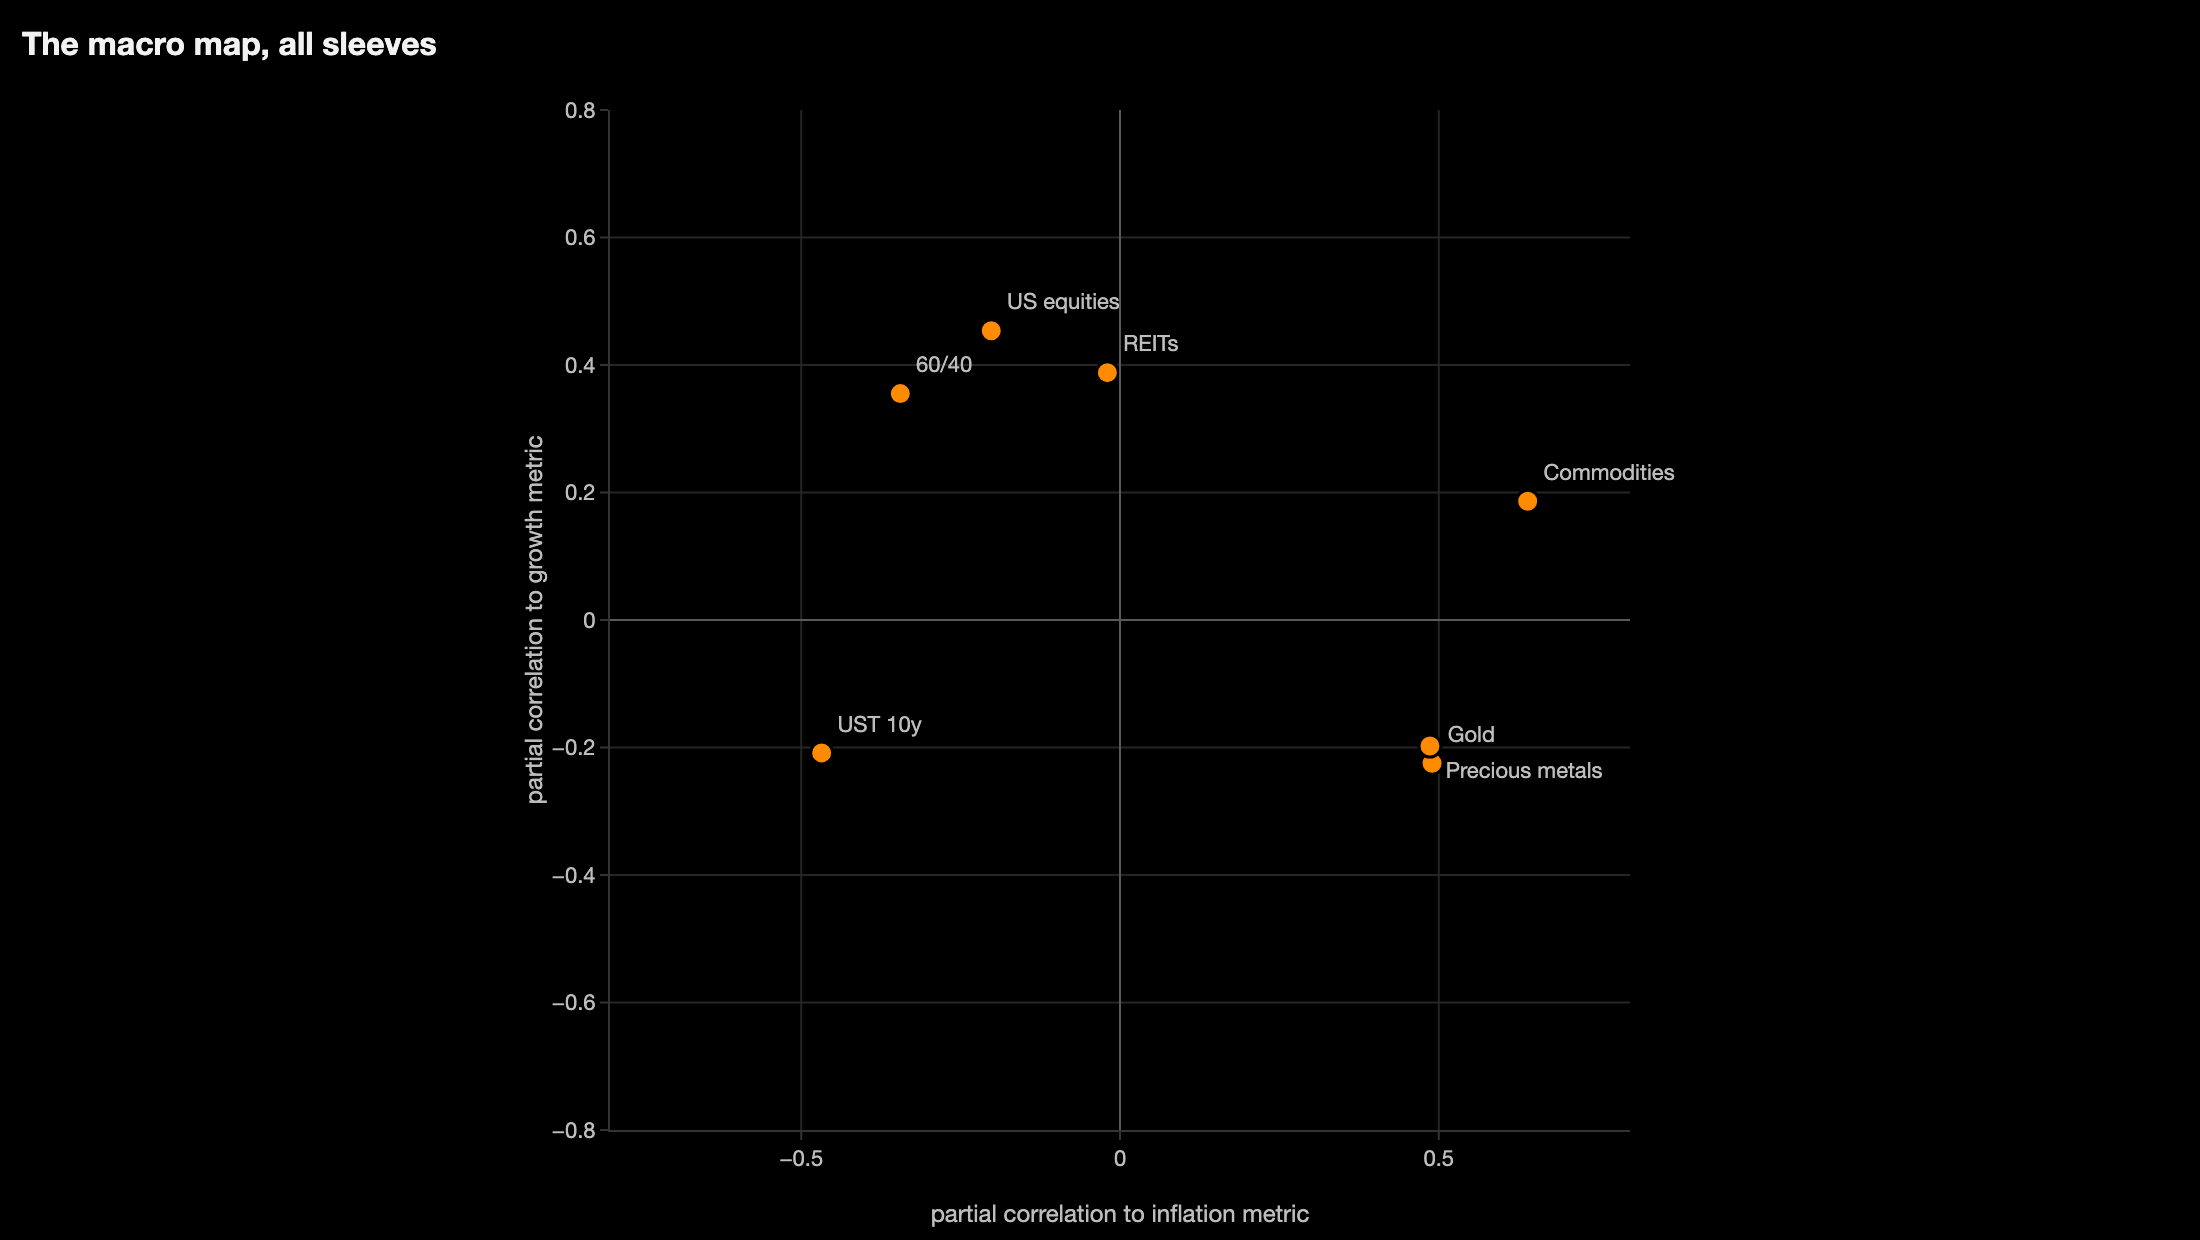

In [19]:
charts.sensitivity_scatter(sensitivities, title="The macro map, all sleeves", limit=0.8).show()

This portion is the extension of the original study. The traditional sleeves cluster in the left half — negative inflation sensitivity, split on growth. 

The real assets occupy the right half:
* Commodities sit top-right: positive to inflation *and* positive to growth. They diversify the inflation exposure but they also double up on the growth exposure.
* Gold and precious metals sit bottom-right: positive to inflation, negative to growth.
* REITs sit almost on the vertical axis, near zero on inflation and around +0.4 on growth. On this evidence they are not an inflation asset: they are equity-like growth exposure. 

That diagonal is the useful fact: an allocation that wants to cut inflation sensitivity without doubling down on growth wants the bottom-right, and one that is happy to take growth risk for a higher long-run premium wants the top-right.

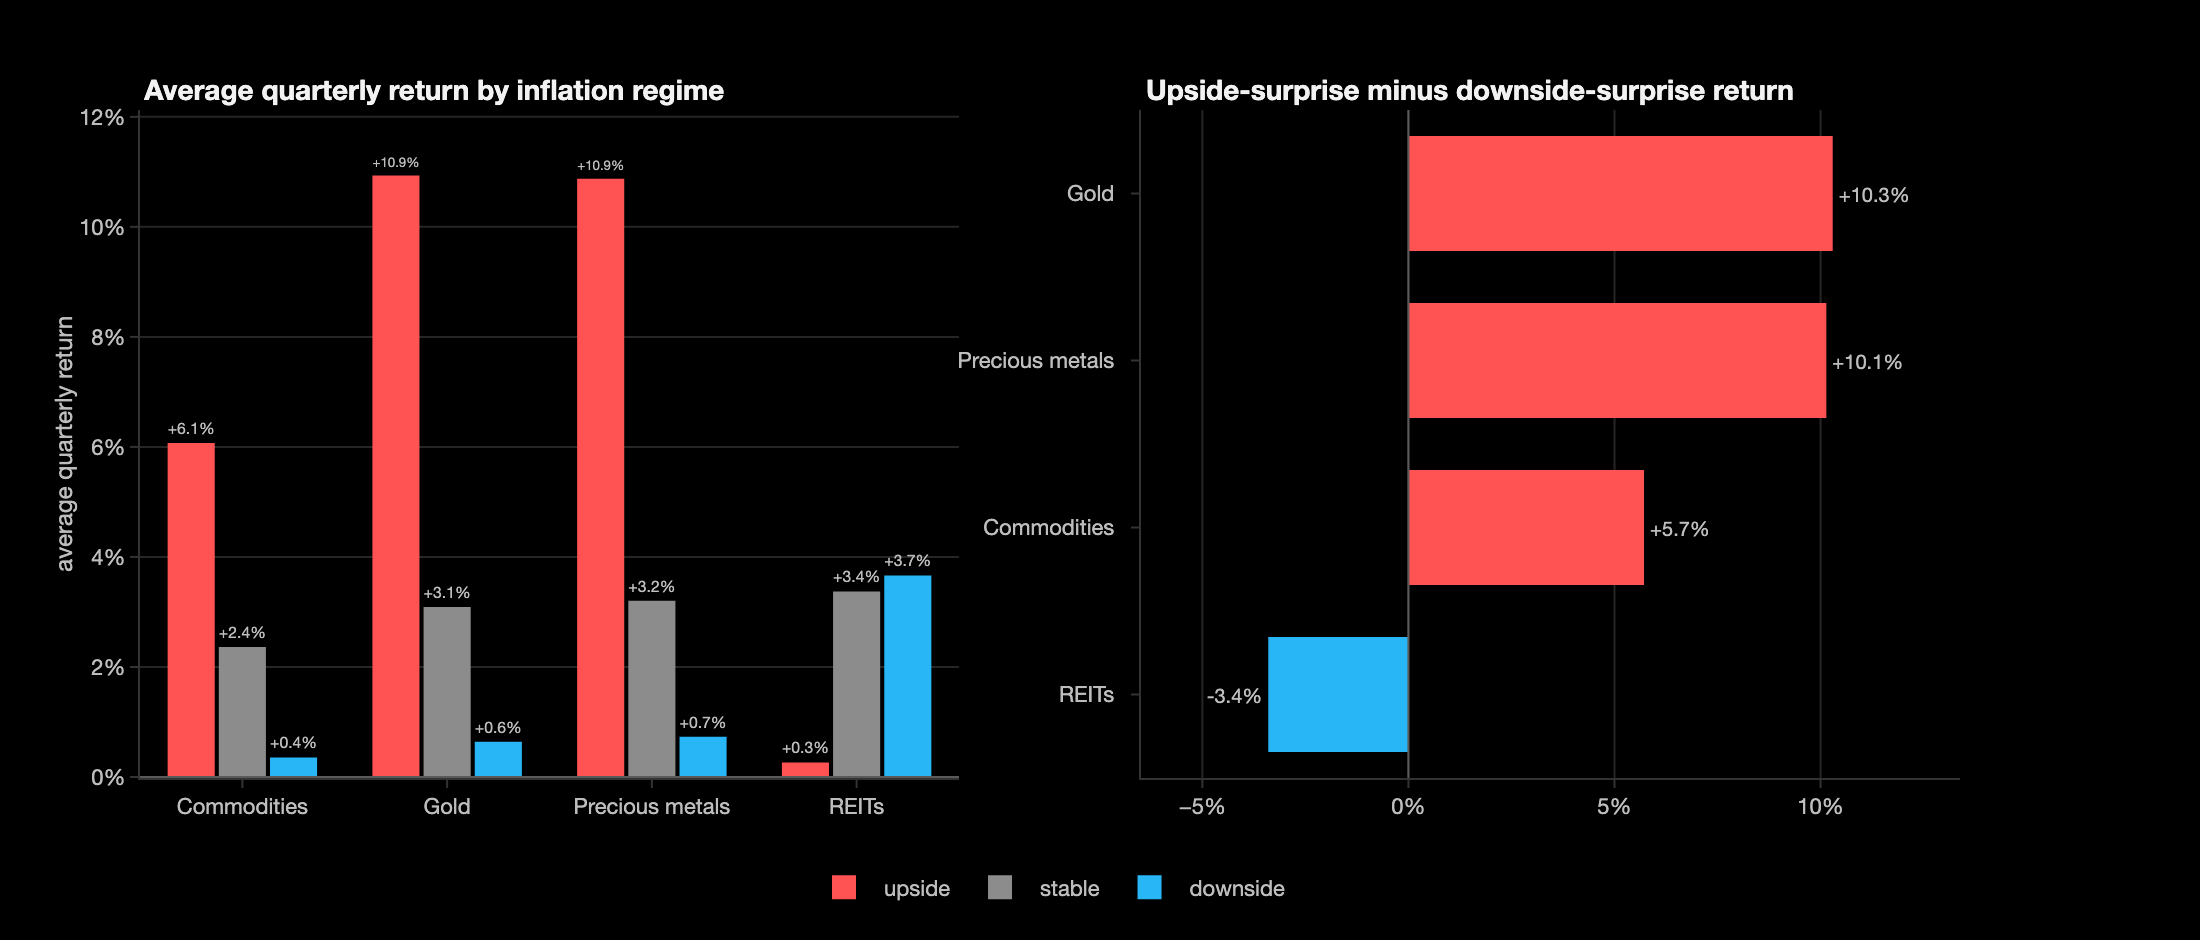

In [20]:
fig = charts.subplots(
    titles=("Average quarterly return by inflation regime", "Upside-surprise minus downside-surprise return"),
    height=470,
)
charts.tritile_bars(regime_averages.loc[REAL], fig=fig, row=1, col=1)
charts.upside_minus_downside(regime_averages.loc[REAL], fig=fig, row=1, col=2)
fig.show()

### Drilling down further into US REITs

Beyond the near-zero correlation to inflation, REITs' average return in upside-surprise quarters is close to zero, and that average is itself a blend of episodes that behaved very differently. The upside-surprise quarters, grouped by episode:

In [21]:
# REIT returns in each upside-surprise quarter, grouped by inflation episode.
if "reits" in REAL:
    upside_quarters = classification[classification == "upside"].index
    reit_upside = quarterly_returns["reits"].reindex(upside_quarters)
    episode = pd.cut(
        upside_quarters.year,
        bins=[1970, 1976, 1990, 2015, 2100],
        labels=["1973-75", "1978-80", "2005-11", "2021 onward"],
    )
    by_episode = reit_upside.groupby(episode, observed=True).agg(["count", "mean", "min", "max"])
    print("REIT quarterly return (%) in upside-surprise quarters, by episode\n")
    print(by_episode.round(1).to_string())
    print(f"\nall upside quarters: {reit_upside.mean():.2f}% average over {len(reit_upside)}")
    print("\n2021 onward, quarter by quarter:")
    print(reit_upside.loc[pd.Period("2021Q1", freq="Q"):].round(1).to_string())

REIT quarterly return (%) in upside-surprise quarters, by episode

             count  mean   min   max
1973-75          7  -5.1 -15.0   6.7
1978-80          7   5.7  -4.5  14.8
2005-11          5   1.0 -15.1  10.0
2021 onward      6  -0.4 -14.7  16.2

all upside quarters: 0.26% average over 25

2021 onward, quarter by quarter:
date
2021Q2    12.0
2021Q3     0.2
2021Q4    16.2
2022Q1    -5.3
2022Q2   -14.7
2022Q3   -10.8
Freq: Q-DEC


>From Claude:
>
>REITs split sharply by episode. They did well through 1978–80, badly through 1973–74, and were mixed through 2005–11. The 2021–22 episode shows both behaviours within six quarters: strong gains while inflation news arrived alongside the reopening boom, then losses of roughly 5%, 15% and 11% in three consecutive upside-surprise quarters once it arrived as a rate shock — a levered, long-duration, income-paying asset class behaving accordingly.
>
>So the summary of the REIT sleeve is: **near-zero *linear* sensitivity to inflation news, and an upside-tail average near zero that is really a wide dispersion across episodes**.

### Are the sensitivities stable over time?

>From Claude:
>
>Every sensitivity above is a single number for the whole sample. The first chart plots each quarter's year-on-year return against the inflation metric, coloured by date: if an asset's relationship with inflation news had drifted, its early and late points would separate. Use the dropdown to switch asset — it includes the backtest-only sleeves from Part 5.
>
>The second chart puts a number on it: the correlation over a rolling ten-year (40-quarter) window. Four core sleeves are shown; click others in the legend to add them. These are simple correlations, not the growth-controlled partials of the macro map, so they read slightly differently.

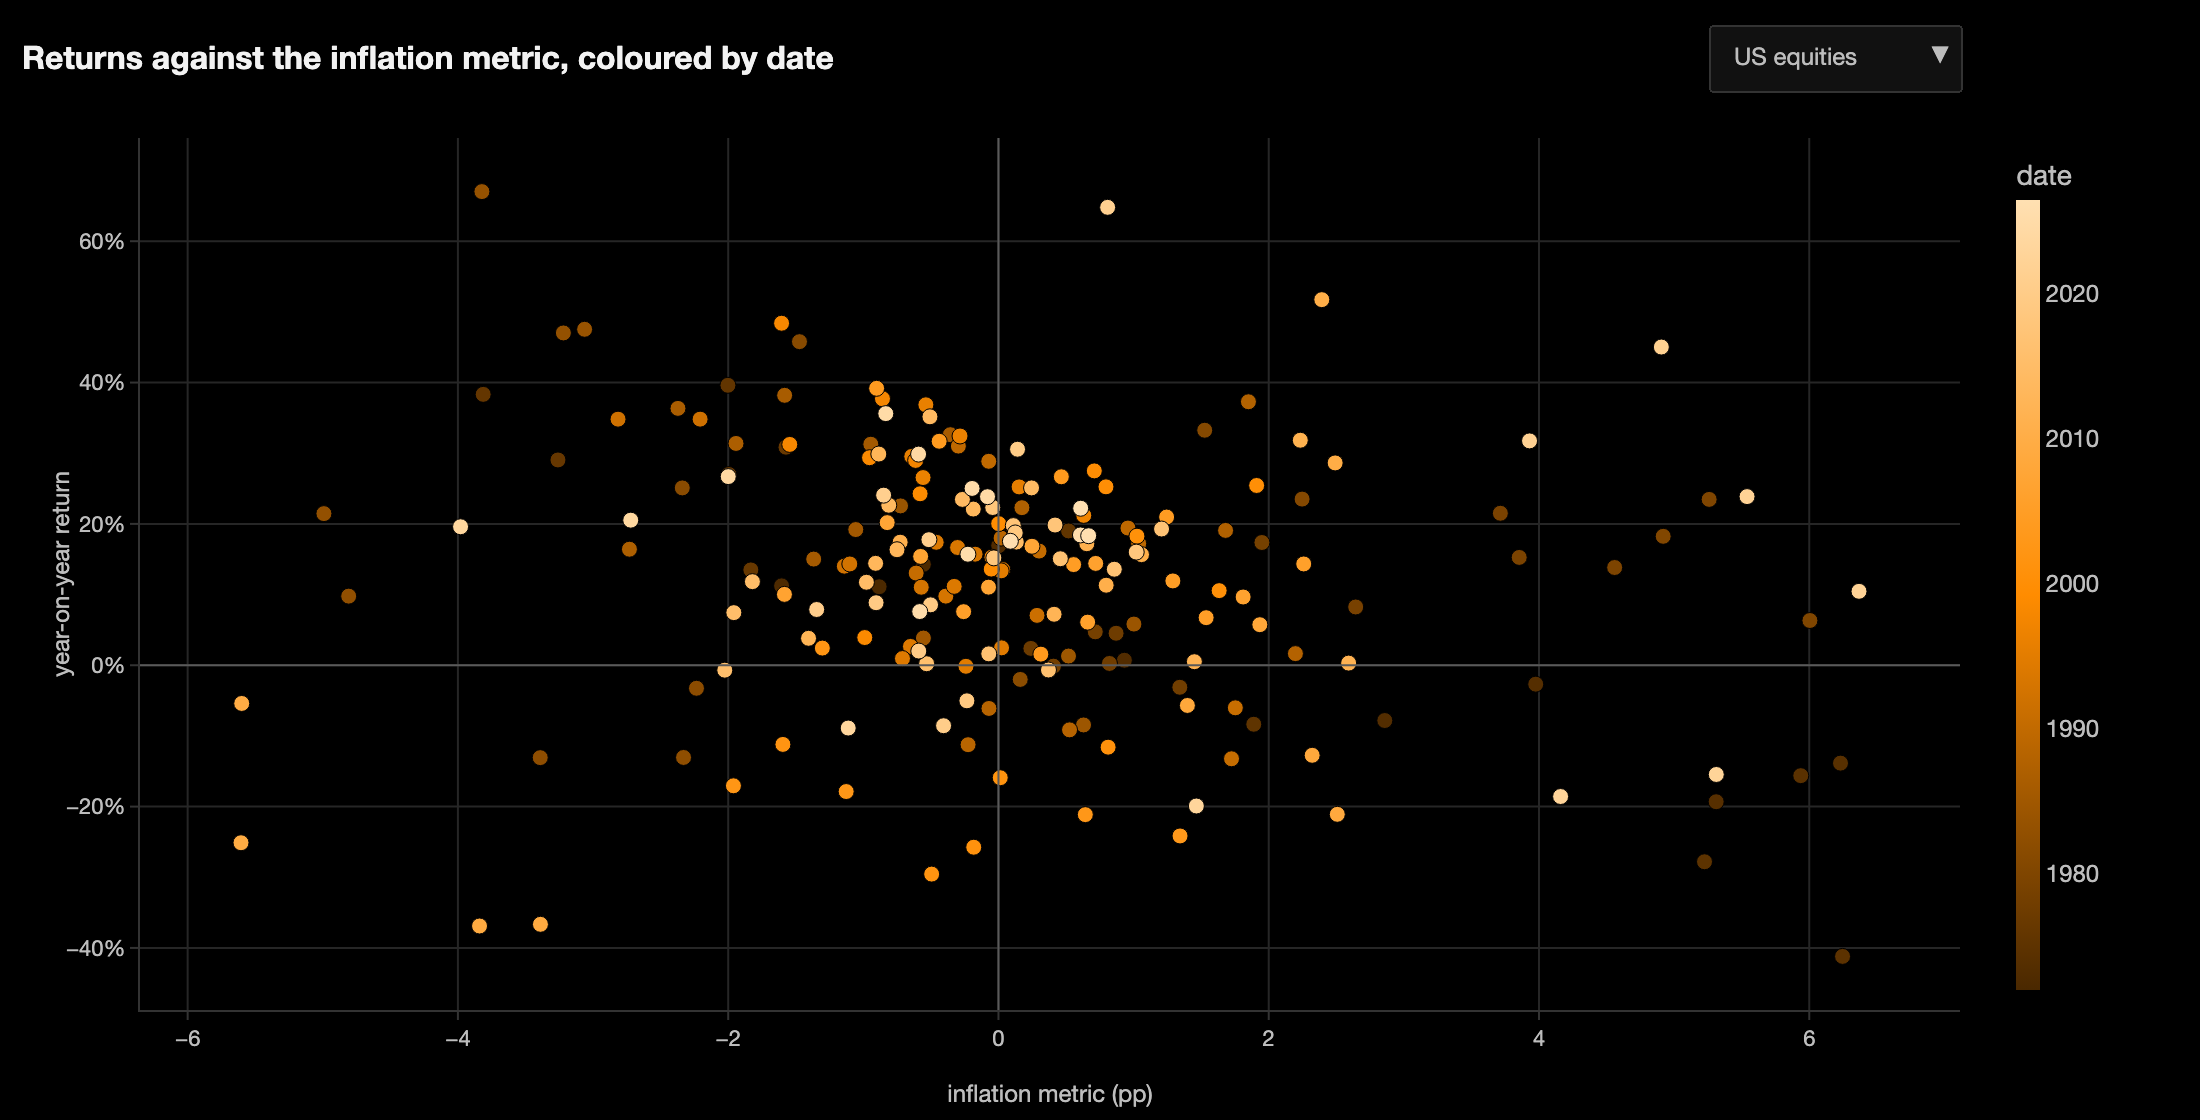

In [22]:
extended_universe, universe_notes = dataset.backtest_universe(monthly)
yoy_universe = dataset.quarterly_yoy_returns(extended_universe).loc[STUDY_START:]
EXTRA = [s for s in ["ust_5y", "ust_20y", "govt_fund", "tips", "ig_model", "ig_fund", "hy_fund", "em_debt", "gsci"]
         if s in yoy_universe]
if universe_notes["missing"]:
    print("unavailable from Yahoo this run:", universe_notes["missing"])

charts.correlation_scatter(yoy_universe[TRADITIONAL + REAL + EXTRA], inflation["combined"]).show()

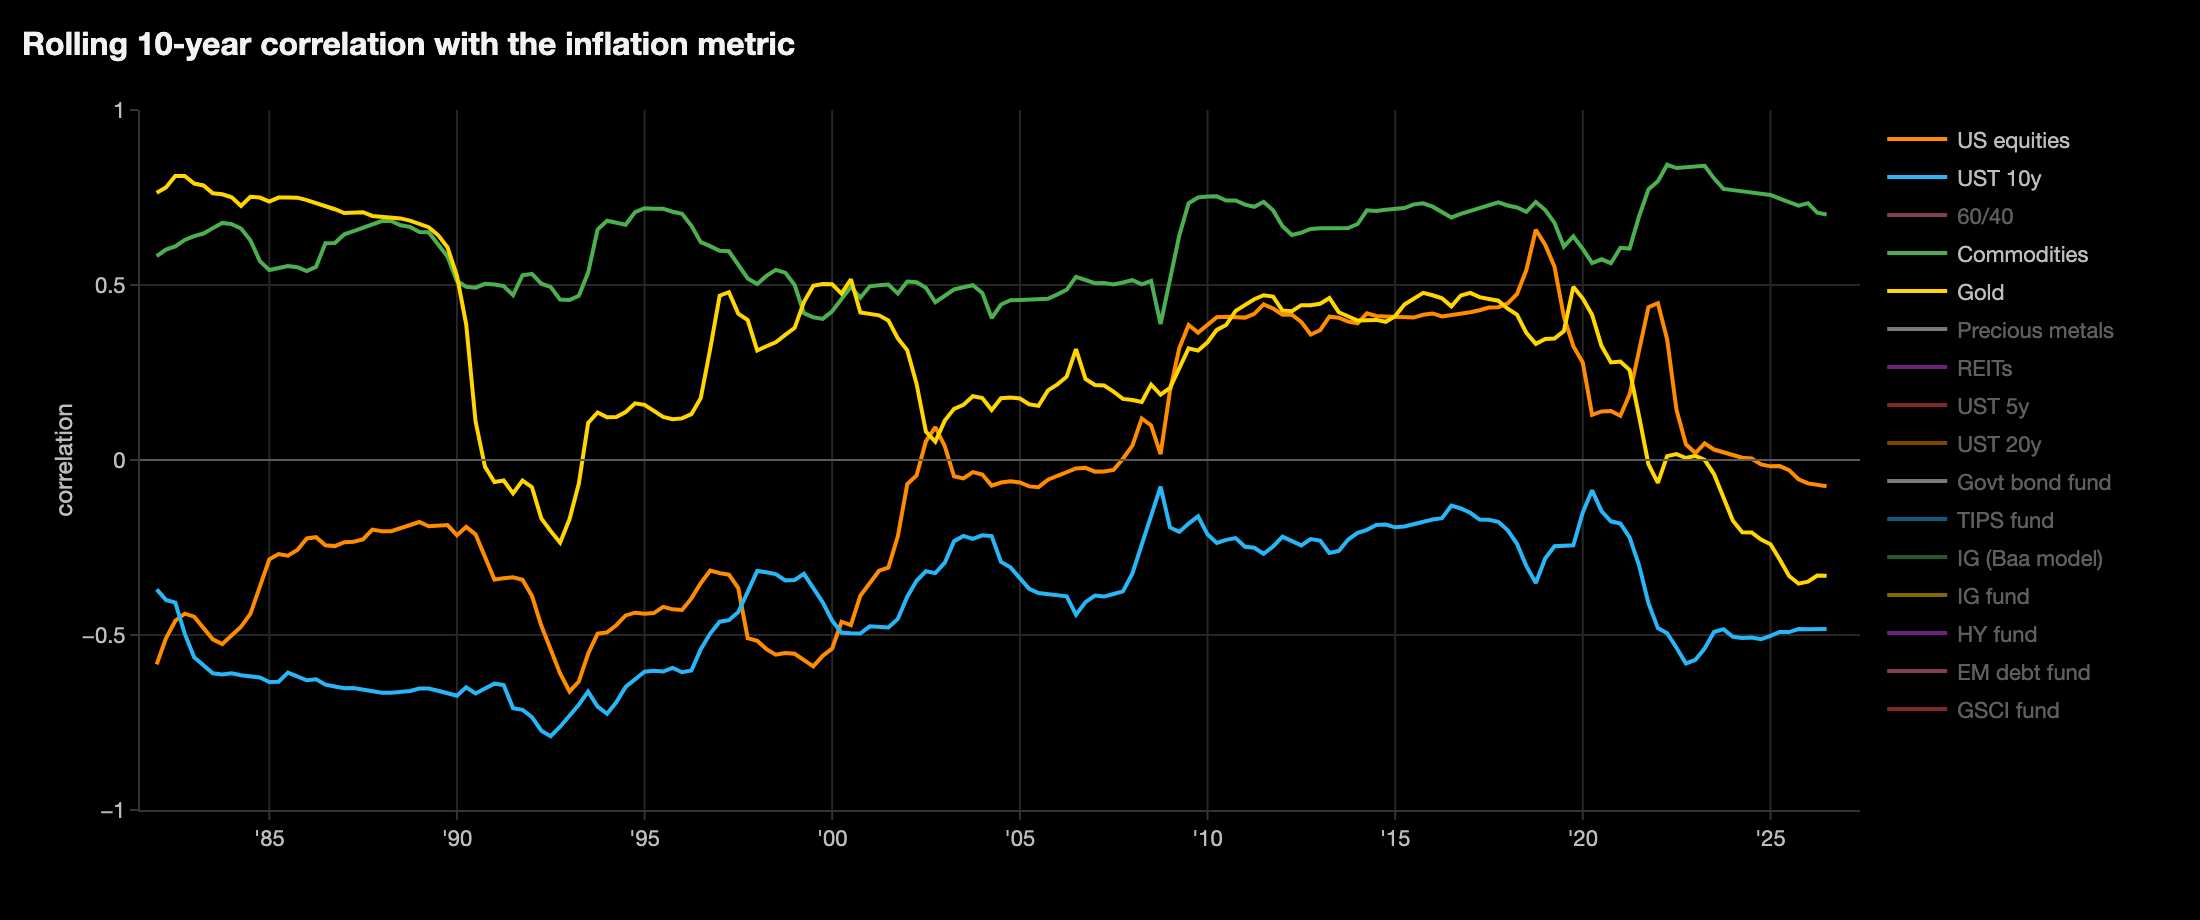

,full sample,lowest 10y,highest 10y,latest 10y,windows with full-sample sign
US equities,-0.19,-0.66,+0.66,-0.07,60%
UST 10y,-0.46,-0.79,-0.08,-0.48,100%
60/40,-0.33,-0.75,+0.66,-0.25,69%
Commodities,+0.63,+0.39,+0.84,+0.70,100%
Gold,+0.48,-0.35,+0.81,-0.33,85%
Precious metals,+0.48,-0.35,+0.80,-0.30,85%
REITs,-0.02,-0.78,+0.66,+0.31,60%


In [23]:
charts.rolling_correlation(
    yoy_universe[TRADITIONAL + REAL + EXTRA], inflation["combined"],
    shown=["equities", "ust_10y", "commodities", "gold"],
).show()

rolling = pd.DataFrame(
    {a: yoy_universe[a].rolling(40, min_periods=40).corr(inflation["combined"]) for a in TRADITIONAL + REAL}
)
full_sample = {a: yoy_universe[a].corr(inflation["combined"]) for a in TRADITIONAL + REAL}
stability = pd.DataFrame({
    "full sample": full_sample,
    "lowest 10y": rolling.min(),
    "highest 10y": rolling.max(),
    "latest 10y": rolling.ffill().iloc[-1],
    "windows with full-sample sign": {a: (rolling[a].dropna() * full_sample[a] > 0).mean() for a in rolling},
}).rename(index=charts.label)
stability.style.format({c: "{:+.2f}" for c in stability.columns[:4]} | {"windows with full-sample sign": "{:.0%}"})

>From Claude:
>
>**Two sleeves are stable, and they are the two the study leans on hardest.** Treasuries are negatively correlated with inflation news in every ten-year window since 1982, and commodities positively in every window. The strength moves around, but the sign never does.
>
>**Equities are not stable.** Their correlation runs from about −0.66 to +0.66 across windows and keeps its full-sample sign in only about 60% of them: clearly negative through the 1980s and 1990s, positive through most of the 2010s, near zero in the latest decade. The small full-sample equity sensitivity is therefore an average over regimes rather than a steady property. That is consistent with the idea that inflation news reads as bad news for equities when inflation is high and as reflation — good news — when it is low.
>
>**Gold is mostly but not always positive.** It keeps its sign in about 85% of windows, but has turned negative (around −0.3) in the latest decade: gold went nowhere during the 2022 surprise and rallied hard afterwards as inflation news faded. The full-sample reading still holds; the recent decade is the exception, and worth watching.

## Part 5 — An "all weather" portfolio

This portion is interactive: see what asset class weights can result in a portfolio with 0 correlation to growth and inflation, across the backtest period.

You could try starting with an illustrative allocation: 60% equities, 25% treasuries, 10% commodities, 15% gold. Those weights sum to 110%, so the panel rescales them to 100% by default (`normalise=True`).

>From Claude:
>
>The app extends the study's universe with sleeves whose histories start later: 5- and 20-year Treasuries, a government bond fund, a TIPS fund, investment-grade credit (a modelled Baa series and a fund), high yield, EM debt, a GSCI fund, and cash (the one-month T-bill return). Their sources are in the Data provenance table at the top. Not every sleeve exists over every window, so the **horizon** selector offers three: the full sample from 1972; since 1986, when the credit and government funds begin; and since 2007, when every sleeve is available. Sleeves without continuous history over the chosen horizon are greyed out, with the date each becomes available.
>
>Below the charts, a statistics table compares the portfolio with US equities, the 10-year Treasury and the 60/40 over exactly the same months; the Sharpe and Sortino ratios are measured against the T-bill return over those months, not a fixed rate.
>
>Shorter horizons hold far fewer inflation surprises (the table below counts them), so treat their sensitivities as indicative rather than tested.

In [24]:
tables = portfolio.horizon_tables(extended_universe, inflation, growth)
pd.DataFrame({
    horizon: {
        "starts": start,
        "sleeves available": len(portfolio.available_sleeves(extended_universe, start)),
        "upside-surprise quarters": int((classification.loc[pd.Period(start, freq="M").asfreq("Q"):] == "upside").sum()),
        "downside-surprise quarters": int((classification.loc[pd.Period(start, freq="M").asfreq("Q"):] == "downside").sum()),
    }
    for horizon, start in portfolio.HORIZONS.items()
}).T

,starts,sleeves available,upside-surprise quarters,downside-surprise quarters
Full sample (1972–),1972-01,9,25,25
Since 1986,1986-01,12,11,12
Since 2007,2007-01,16,11,8


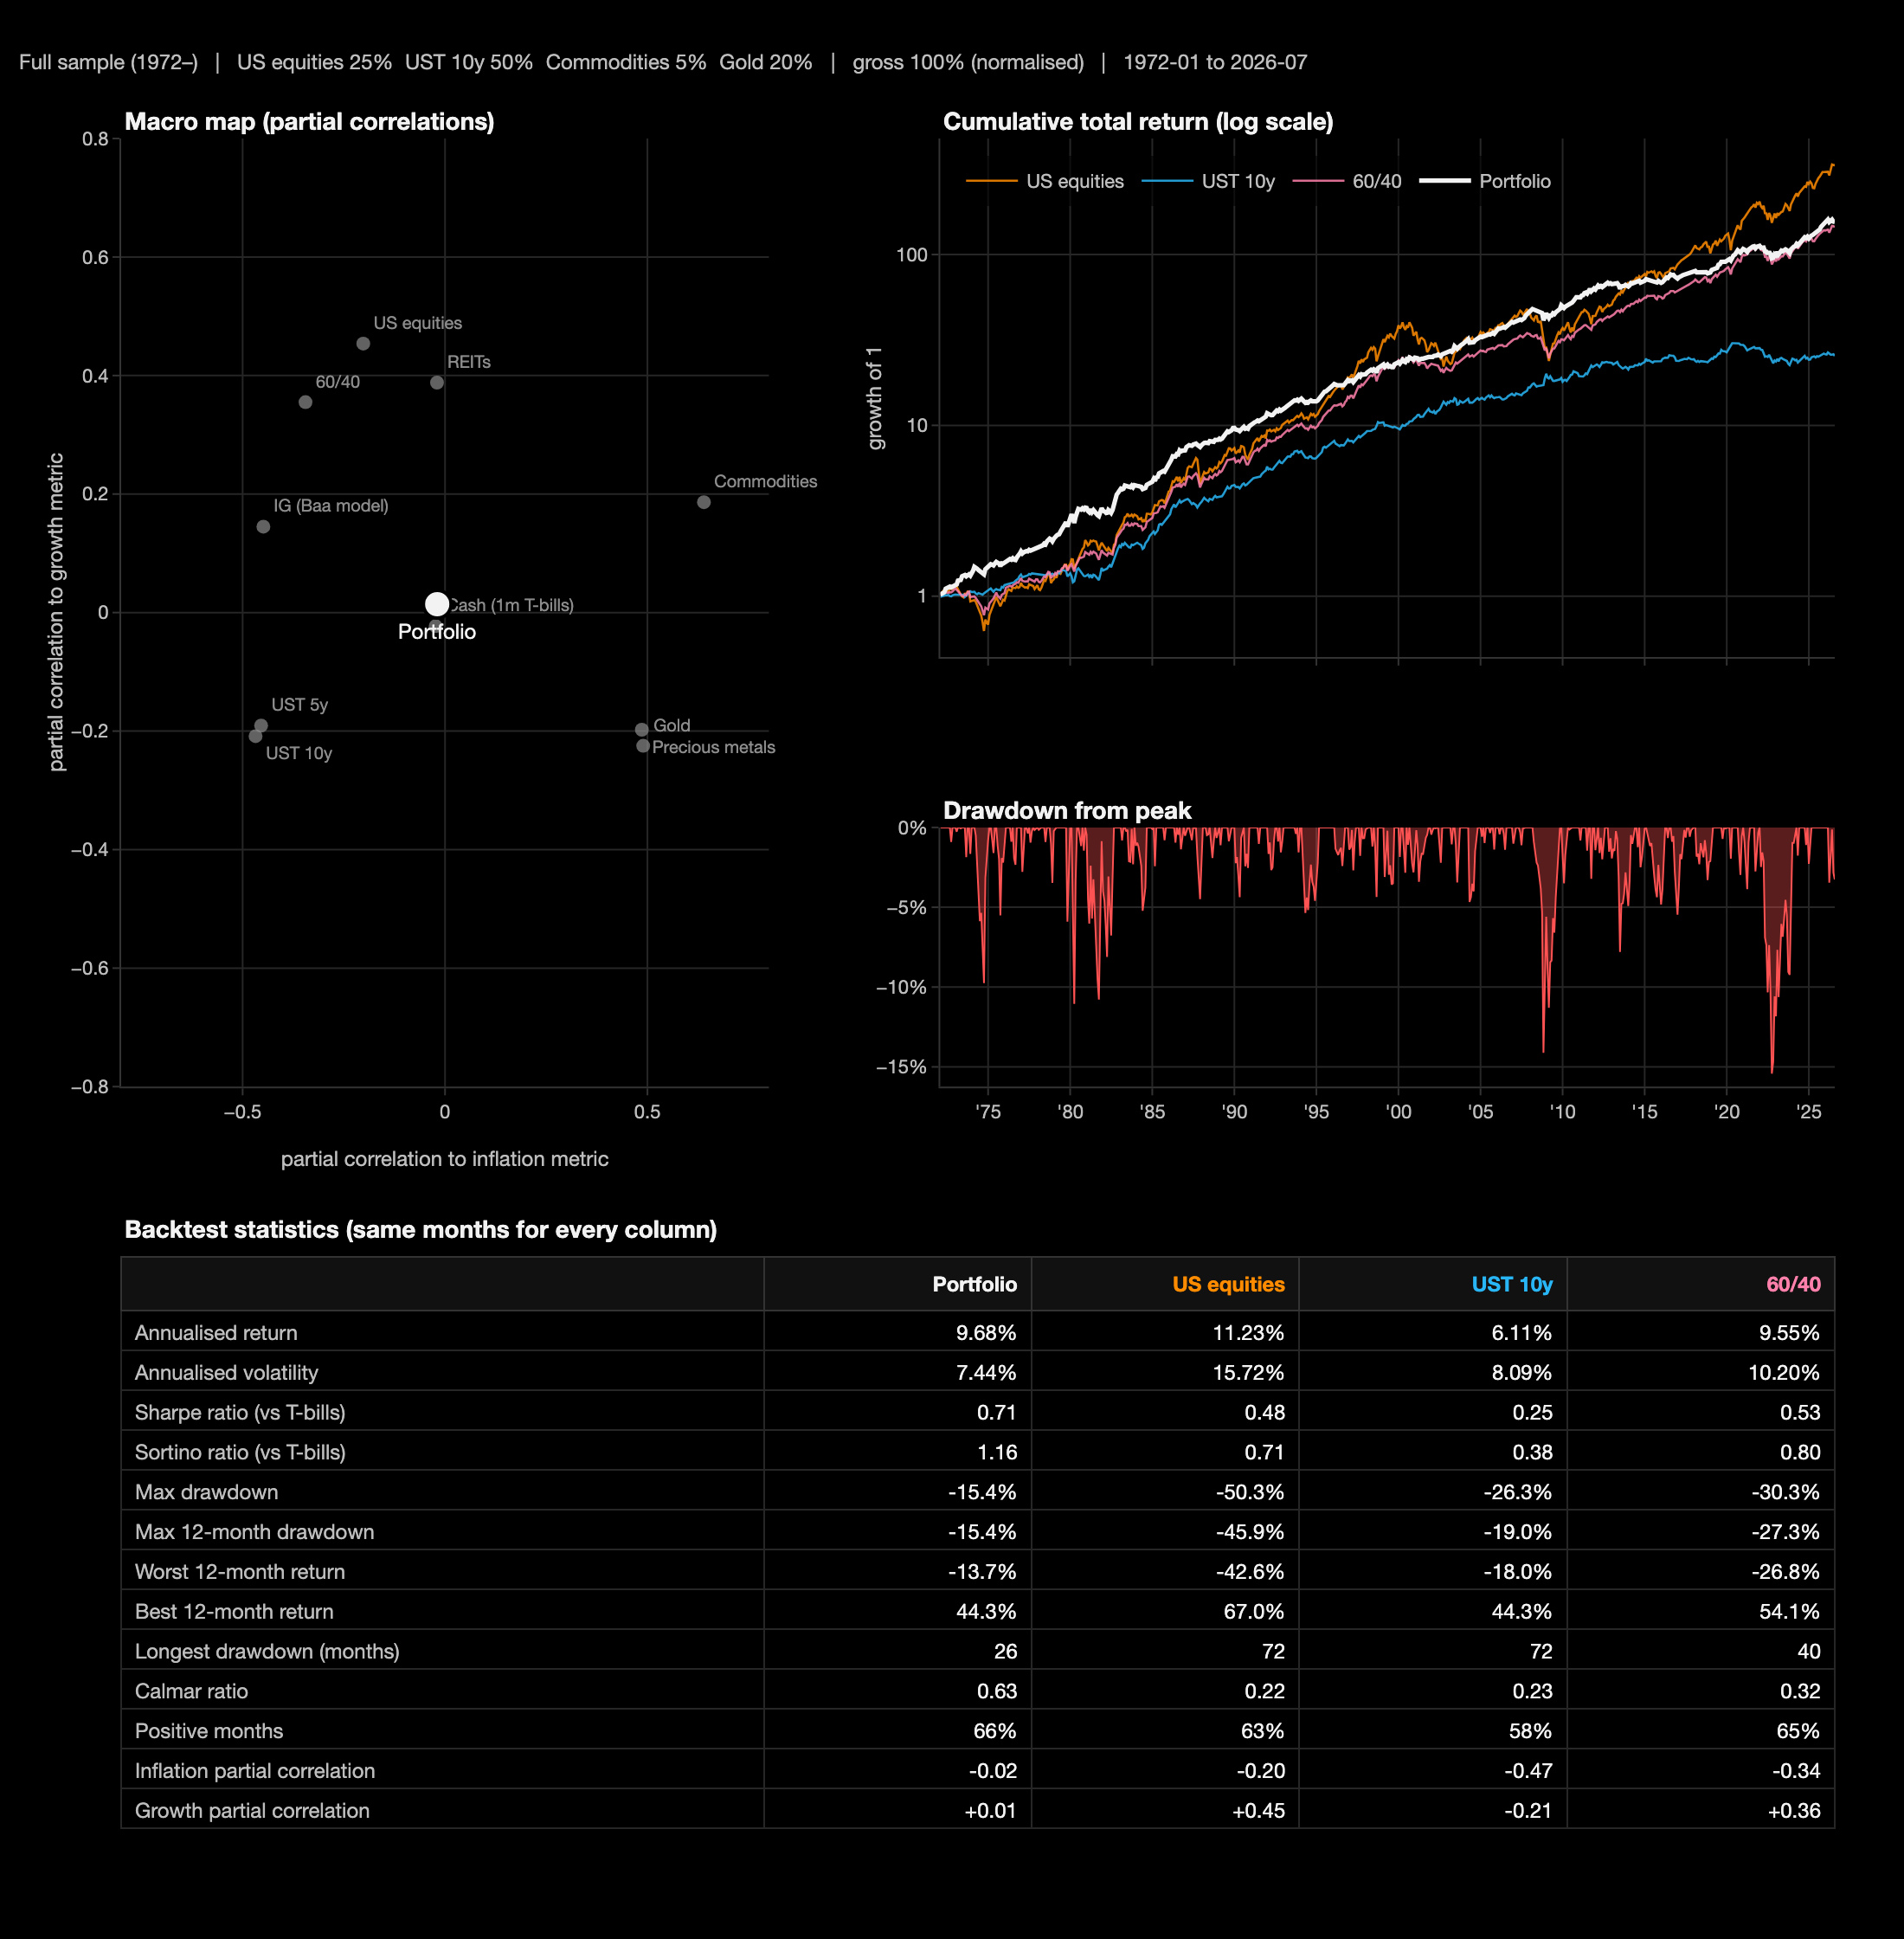

return 9.68%  vol 7.44%  max drawdown -15.43%  Sharpe 0.71

                 inflation partial   growth partial
this portfolio              -0.019           +0.014
60/40                       -0.345           +0.355


In [25]:
fig, stats, panel_table = portfolio.backtest_figure(
    portfolio.EXAMPLE_WEIGHTS, extended_universe, inflation, growth,
    horizon="Full sample (1972–)", normalise=True, tables=tables,
)
fig.show()

print(f"return {stats['annualised_return']:.2%}  vol {stats['volatility']:.2%}  "
      f"max drawdown {stats['max_drawdown']:.2%}  Sharpe {stats['sharpe']:.2f}\n")
print("                 inflation partial   growth partial")
print(f"this portfolio   {panel_table.loc['portfolio', 'infl_partial']:+17.3f}   "
      f"{panel_table.loc['portfolio', 'growth_partial']:+14.3f}")
print(f"60/40            {sensitivities.loc['sixty_forty', 'infl_partial']:+17.3f}   "
      f"{sensitivities.loc['sixty_forty', 'growth_partial']:+14.3f}")

>From Claude:
>
>**The blend does what it was built to do.** Its inflation partial correlation is close to zero, against the 60/40's clearly negative one, while it keeps most of the 60/40's growth exposure. The inflation exposure can be neutralised without giving up the growth exposure.
>
>Two caveats on the headline statistics. Return, volatility and drawdown depend heavily on the proxies: the all-cap equity series is more volatile than a large-cap index, and AQR's equal-weight commodities had a far stronger 1970s than production-weighted indices. And the weights are chosen in-sample — this shows what would have diversified inflation surprises historically, not a strategy anyone could have run in real time.
>
>Set `normalise=False` to run the weights as a 110%-gross portfolio; returns and volatility both scale up by roughly a tenth, as you would expect.

>From Claude:
>
>**This panel is static.** The figure above is drawn for one fixed weight vector and horizon; `portfolio.backtest_figure` redraws it for any other.
>
>The notebook used to carry an ipywidgets copy with a horizon selector and per-sleeve sliders. It was retired on 20-Sep-2026: a Plotly table trace measures its text when first drawn, and a widget is drawn before it is attached to the page, so its headers rendered blank in VS Code. Changing the weights now means editing the call and re-running the cell.


### What it did when the macro actually went wrong

>From Claude:
>
>Everything above is a full-sample statistic, and full-sample statistics make the wrong case for this portfolio. Over fifty years it loses to equities on total return, because fifty years are mostly quiet years -- and the quiet years are exactly the ones it is not for. So here is the other question: in the windows when inflation actually surprised to the upside, or growth to the downside, what did each portfolio lose?
>
>**The windows are derived, not chosen.** An episode is a run of at least two consecutive quarters that this study's own classifier (`metrics.classify`, the same z-score sort the regime charts use) marks as a shock. Nothing is hand-picked and nothing is named, so the set extends itself as data arrives and there is no scope for choosing flattering crises. Reassuringly, it recovers the episodes one would have chosen anyway: 1973-74, 1979-80 and 2021-22 for inflation; 1974-75, 1982, 2008-09 and 2020 for growth.
>
>🚨 This is **ex-post and in-sample**, like everything else in Part 5. The z-score is computed over the whole sample, so an episode is only knowable afterwards and its edges shift slightly as the sample grows. Read it as what happened in the bad windows, never as what a rule would have earned -- nobody knew in 1973 Q2 that the next seven quarters were an episode.

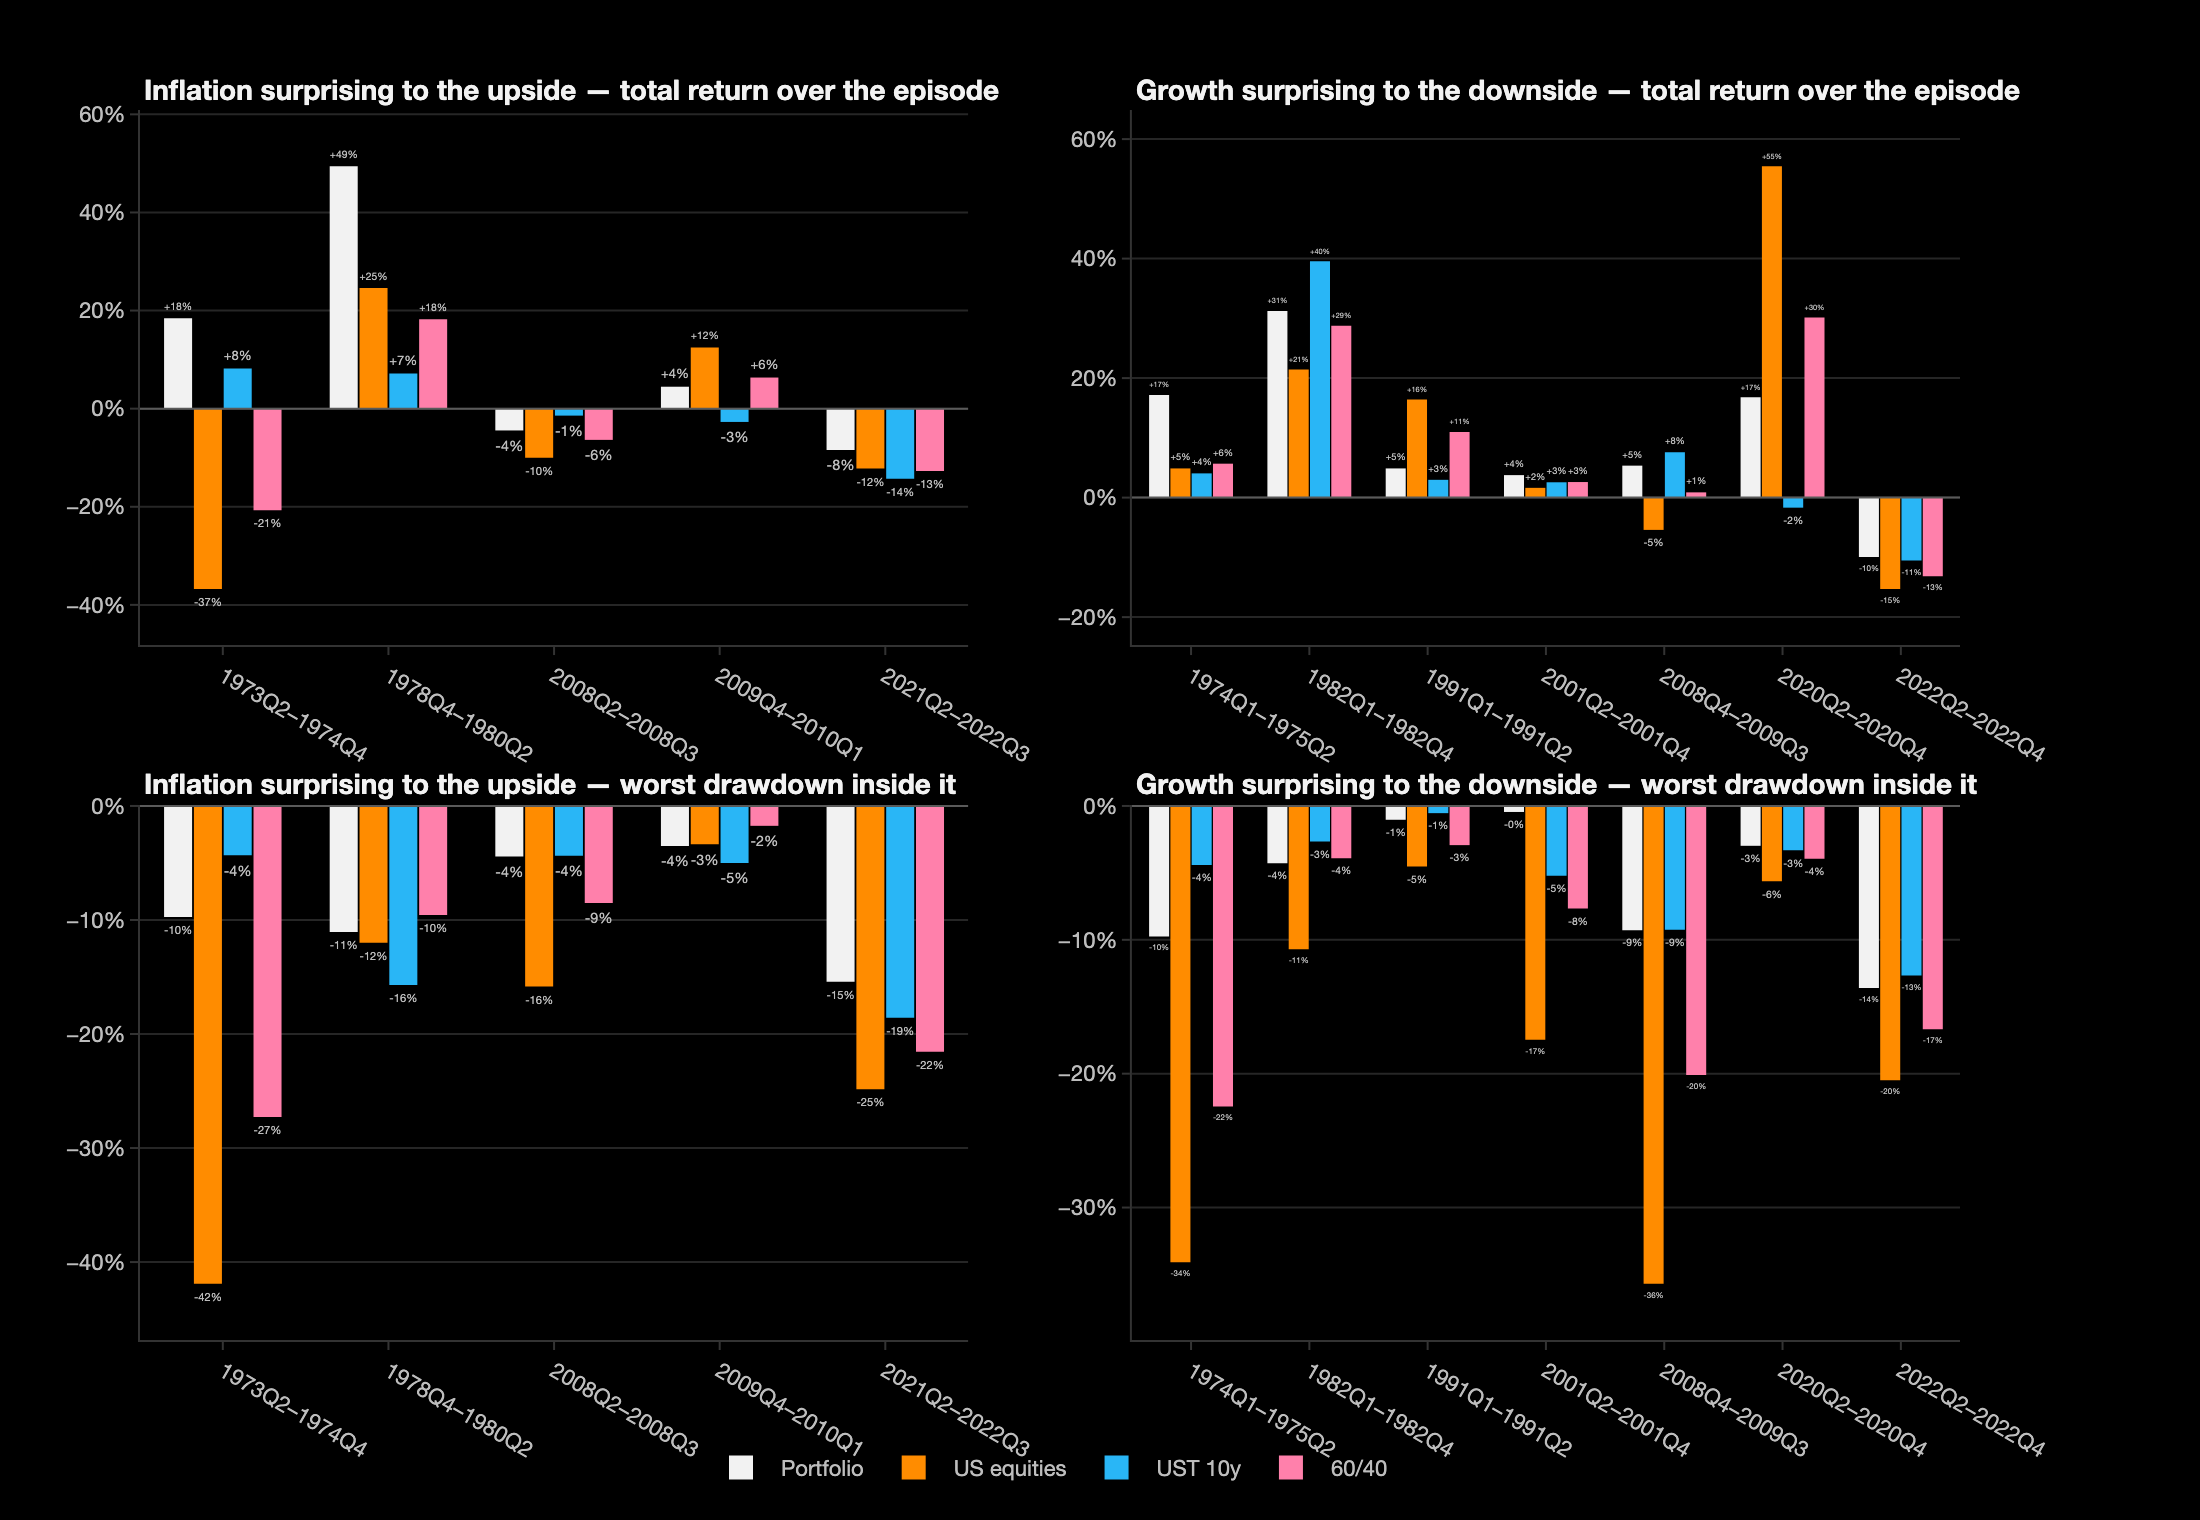

In [26]:
# Shock episodes: contiguous runs of quarters the study's own classifier calls a shock.
shocks = episodes.all_episodes(inflation, growth)
example_returns = portfolio.blend(
    portfolio.EXAMPLE_WEIGHTS, extended_universe, normalise=True, start="1972-01"
)
episode_returns = {
    "portfolio": example_returns,
    **{b: extended_universe[b] for b in portfolio.BENCHMARKS},
}
episode_detail = episodes.episode_table(episode_returns, shocks)
episodes.episode_figure(episode_detail).show()

In [27]:
# Averaged over fully covered episodes only: a sleeve that begins midway through one
# did not live through it, and its drawdown is not comparable.
episodes.summarise(episode_detail).set_index(["kind", "series"]).style.format(
    {
        "mean_return": "{:+.1%}", "worst_return": "{:+.1%}",
        "mean_drawdown": "{:.1%}", "worst_drawdown": "{:.1%}",
    }
)

>From Claude:
>
>**The blend loses roughly half of what equities lose, in both kinds of shock.** Across the five upside-inflation episodes its average worst drawdown is about −12% against equities' −20%, and its deepest is −19% against −42% (1973-74). Across the seven downside-growth episodes it is −11% against −18%. The return comparison is the striking one for inflation specifically: the blend averaged roughly +8% over an inflation episode while equities averaged about −4%.
>
>**Treasuries alone lose less still**, which is worth saying plainly rather than burying. A reader whose only objective is a shallow drawdown in a shock should hold treasuries, not this blend. The blend's case is that it does nearly as well in the shocks while keeping the growth exposure that treasuries give up -- which is the trade the macro map above is about.

#### Recognisable episodes, for reference

>From Claude:
>
>The conventional chronology, for orientation beside the derived windows above. **Nothing here feeds the analysis** — no regression, classification or backtest reads this list. The windows the study measures are derived from the metric precisely so that nobody picks them, and this table exists only so you can see which recognisable event each one lines up against.
>
>US recessions are dated from the NBER's own peak and trough months; the oil shocks and policy episodes use the standard dating. Where a conventional date is contested I have taken the wider reading, since the purpose is orientation rather than precision.
>
>**Every one of the twelve derived windows overlaps at least one named episode.** That is worth stating as a check rather than a coincidence: a rule that fires on noise would produce windows that correspond to nothing. The one that needs the caveat is *Post-GFC base effects* (2009Q4–2010Q2), which is an artefact rather than an event — year-on-year CPI swung from about −2% to +2.7% as the 2008 crash dropped out of the base, with no new inflation impulse behind it. It clears the threshold anyway, which is the honest cost of a rule nobody hand-picks.

In [28]:
episodes.historical_table().style.hide(axis="index").set_properties(
    subset=["What happened"], **{"text-align": "left", "white-space": "normal"}
)

Episode,Kind,From,To,What happened
First oil shock (OPEC embargo),Inflation,1973Q4,1974Q4,"The October 1973 embargo roughly quadrupled the crude price. Inflation and recession arrived together, which is what made it the canonical stagflation."
1973–75 recession,Growth,1973Q4,1975Q1,NBER peak November 1973 to trough March 1975. The deepest post-war contraction until 2008.
Second oil shock (Iranian revolution),Inflation,1979Q1,1980Q2,"Supply disruption after the revolution, on top of already-elevated inflation expectations."
Volcker disinflation,Growth,1981Q3,1982Q4,"The Fed drove the funds rate through 19% to break inflation. Two recessions in three years, and the reason a credible inflation-fighting central bank is priced differently."
Gulf War oil spike,Inflation,1990Q3,1991Q1,"Crude roughly doubled on the invasion of Kuwait, then gave it back quickly. A short, sharp supply shock."
1990–91 recession,Growth,1990Q3,1991Q1,NBER peak July 1990 to trough March 1991.
Dot-com bust,Growth,2001Q1,2001Q4,NBER peak March 2001 to trough November 2001. An equity and capex bust rather than a consumer one.
Global financial crisis,Growth,2007Q4,2009Q2,"NBER peak December 2007 to trough June 2009. The deepest contraction in the sample, and the episode most readers picture when they think about diversification failing."
2008 commodity spike,Inflation,2007Q4,2008Q3,"Crude peaked near $147 in July 2008, months into the recession — a reminder that an inflation shock and a growth shock can overlap."
Post-GFC base effects,Inflation,2009Q4,2010Q2,"⚠️ Not an event — an artefact. Year-on-year CPI swung from about −2% to +2.7% as the 2008 crash dropped out of the base, with no new inflation impulse. It clears the study's threshold and is therefore a derived episode, which is the honest cost of a rule nobody hand-picks: the year-on-year window can manufacture a surprise out of the comparison period alone."


## Concluding remarks (re Claude)

**What is robust.**
* Treasuries have a large, statistically robust negative sensitivity to inflation surprises -- and it is the one result that holds in *every* ten-year window since 1982, not merely on average.
* Commodities are the mirror image: positively correlated with inflation news in every ten-year window. Treasuries and commodities are the two sleeves the study leans on hardest, and they are the two whose sign never moves.
* The 60/40's inflation exposure is concentrated -- the two sleeves hedge each other's growth risk but share each other's inflation risk.
* Gold and precious metals have positive full-sample inflation sensitivity that survives controlling for growth, and the metals achieve it from the opposite growth quadrant to equities.

**What needs qualifying.**
* **Equities are the weakest claim here, and the reason is not the horizon.** Whether the small negative sensitivity clears statistical significance does depend on the measurement window -- it does not at the year-on-year window this study uses, and does at quarterly and monthly windows, which trade correlation for observations. But the rolling-window section is the more serious qualification: the equity correlation runs from about −0.66 to +0.66 across ten-year windows and keeps its full-sample sign in only around 60% of them. It was clearly negative through the 1980s and 1990s, positive through most of the 2010s, and near zero in the latest decade. The full-sample number is an **average over regimes, not a property of the asset** -- consistent with inflation news reading as bad news when inflation is high and as reflation when it is low. "Real but small" was the earlier reading; "regime-dependent" is the better one.
* **Gold is mostly but not always positive.** It keeps its sign in about 85% of ten-year windows, but has been negative (around −0.3) in the latest decade: gold went nowhere during the 2022 surprise and rallied hard afterwards as inflation news faded. The full-sample reading still holds. The recent decade is the exception, and is worth watching rather than explaining away.

**The 2022–23 episode.**
* This is the largest upside surprise in the sample, and it strengthens every real-asset result.
* That is reassuring for the thesis and also exactly what one would expect from a confirming episode in a 50-year sample.

**What the portfolio is actually for.**
* Over the full sample the blend loses to equities on total return, and that is the honest headline. The shock-episode table is the answer to it: across the five upside-inflation episodes the blend averaged a −12% worst drawdown against equities' −20%, and across the seven downside-growth episodes −11% against −18%, for much the same return. It is bought for the windows, not for the average.
* Its inflation partial correlation is close to zero against the 60/40's clearly negative one, while it keeps most of the 60/40's growth exposure. That is the whole design: neutralise the inflation exposure without giving up the growth exposure.

**A major caveat.**
* Every classification here uses a full-sample z-score, and every weight in Part 5 is chosen in-sample. That applies to the shock episodes too -- their boundaries are only knowable after the fact. This is a study of what diversified inflation surprises *historically*, not a backtest of a strategy that could have been run.


## Appendix A — Reconstructing treasury total returns

FRED publishes constant-maturity *yields*, not total returns. Following Swinkels (2019), treat the constant-maturity point as a par bond with semi-annual coupons and take its return to second order:

$$D_t = \frac{1}{Y_t}\left[1 - \frac{1}{(1 + 0.5 Y_t)^{2 M_t}}\right]$$

$$C_t = \frac{2}{Y_t^2}\left[1 - \frac{1}{(1+0.5Y_t)^{2M_t}}\right] - \frac{2 M_t}{Y_t (1+0.5Y_t)^{2M_t + 1}}$$

$$r_t = \frac{Y_{t-1}}{12} - D_{t-1}\,\Delta Y_t + \tfrac{1}{2} C_{t-1} (\Delta Y_t)^2$$

**A note on the convexity term.** The exponent $2M+1$ applies to the compounding factor $(1+0.5Y_t)$ alone. It is easy to transcribe with the bracket around the whole product, $[Y_t(1+0.5Y_t)]^{2M+1}$; at Y=5%, M=10 that version is some twenty orders of magnitude too large and the convexity term swamps the return. The correct form gives the ~74 years² a 10-year par bond should have.

**A sampling trap worth more than it looks.** FRED's monthly `GS10` is a *monthly average* of daily yields, so differencing it smears each month's yield move across two months. Using it, the reconstruction correlates 0.72 with IEF; taking month-end values from the daily `DGS10` instead — same formula — gives 0.99. Everything here uses month-end values from the daily series.

In [29]:
print("duration and convexity of a par bond at selected yields:")
for yield_level in (0.02, 0.05, 0.10, 0.15):
    print(f"  Y={yield_level:.0%}  M=10y   D={bondmath.modified_duration(yield_level, 10):6.3f}"
          f"   C={bondmath.convexity(yield_level, 10):7.2f}")

print("\nvalidation against IEF (iShares 7-10y treasury), monthly:")
for key, value in dataset.validate_treasury_reconstruction().items():
    print(f"  {key:26s} {value if not isinstance(value, float) else round(value, 3)}")
print("\nIEF is a 7-10y ladder, not a constant-maturity 10y par bond, so its volatility is")
print("lower by construction. The correlation is the test; the level difference is expected.")

duration and convexity of a par bond at selected yields:
  Y=2%  M=10y   D= 9.023   C=  90.85
  Y=5%  M=10y   D= 7.795   C=  73.63
  Y=10%  M=10y   D= 6.231   C=  52.83
  Y=15%  M=10y   D= 5.097   C=  38.76

validation against IEF (iShares 7-10y treasury), monthly:
  months                     289
  correlation                0.99
  model_annualised_vol       7.591
  ief_annualised_vol         6.627
  model_annualised_return    2.947
  ief_annualised_return      3.484

IEF is a 7-10y ladder, not a constant-maturity 10y par bond, so its volatility is
lower by construction. The correlation is the test; the level difference is expected.


## Appendix B — Implementation map

The study runs on index and academic series because they reach back to 1972. Anyone actually taking these exposures would use funds, so the mapping is below, with each fund's genuine first month of data fetched rather than recalled. The inception dates are themselves the argument for using long-history proxies in the study: the ETF era contains barely one inflation episode.

In [30]:
CANDIDATE_ETFS = {
    "equities": ["VTI", "SPY"],
    "treasuries": ["IEF", "TLT"],
    "commodities": ["GSG", "DBC", "PDBC"],
    "gold": ["GLD", "IAU"],
    "precious metals": ["SLV"],
    "REITs": ["VNQ"],
    "TIPS / breakevens": ["TIP", "SCHP"],
}

rows = []
for sleeve, tickers in CANDIDATE_ETFS.items():
    for ticker in tickers:
        try:
            history = sources.yahoo_monthly_total_return(ticker)
            rows.append({
                "sleeve": sleeve, "ticker": ticker,
                "first month": str(history.index.min()),
                "months": len(history),
                "years": round(len(history) / 12, 1),
            })
        except Exception as error:
            rows.append({"sleeve": sleeve, "ticker": ticker, "first month": f"unavailable ({error})",
                         "months": 0, "years": 0.0})

etf_map = pd.DataFrame(rows)
print(f"longest available history: {etf_map['years'].max():.1f} years — the study covers "
      f"{len(yoy_returns) / 4:.0f}")
etf_map

longest available history: 33.6 years — the study covers 55


,sleeve,ticker,first month,months,years
0,equities,VTI,2001-07,302,25.2
1,equities,SPY,1993-02,403,33.6
2,treasuries,IEF,2002-08,289,24.1
3,treasuries,TLT,2002-08,289,24.1
4,commodities,GSG,2006-08,241,20.1
5,commodities,DBC,2006-03,246,20.5
6,commodities,PDBC,2014-12,141,11.8
7,gold,GLD,2004-12,261,21.8
8,gold,IAU,2005-02,259,21.6
9,precious metals,SLV,2006-05,244,20.3


## Appendix C — Ideas for further work

* **Equity-style and sector drill-downs**: value versus growth from Ken French's 6 portfolios (1926–), and sector sensitivities along the lines of Lau and Botte (2022).
* **Longer histories for the backtest-only sleeves.** Free credit-index histories stop at 1985 (Yahoo's fund data) or three years back (FRED's ICE BofA indices), and TIPS before 2000 would need synthetic real returns built from survey inflation expectations.
* **Out-of-sample regime classification.** Every z-score here uses the full sample; an expanding-window version would show how the regimes looked in real time.
* **A commodity series that does not need splicing.** AQR's file stops in May 2025 and the tail is GSG. If a live equal-weight series turns up, the splice goes away.
* **Other commodity benchmarks, and selectable universes for the backtest app.** The backtest fixes one commodity series and one sleeve list; letting the reader choose between benchmarks — production-weighted against equal-weight, say — would show how much of the real-asset result is the benchmark rather than the asset class.


## References

1. **Thapar, A., T. Maloney and A. Brixton (2021).** "When Stock-Bond Diversification Fails: Managing inflation risk in investor portfolios." AQR Capital Management, October 2021. *The source of the change/surprise/combined metric, the tritile sort, and the two-factor partial correlation framing.*
2. **Lau, S. and A. Botte (2022).** "A Machine Learning Approach to Constructing an Inflation-Themed Equity Portfolio." Two Sigma Street View, 26 January 2022. *The source of the inflation-level bucketing (high/medium/low) that Part 1 discusses and rejects in favour of surprises, and of the sector/style drill-down idea in Appendix C.*
3. **Swinkels, L. (2019).** "Treasury bond return data starting in 1962." *Data in Brief* 24. *The par-bond duration/convexity reconstruction in Appendix A.*
4. **Levine, A., Y. H. Ooi, M. Richardson and C. Sasseville (2018).** "Commodities for the Long Run." *Financial Analysts Journal* 74(2). *The commodity series used here, via AQR's public data library.*

### Data sources

| Source | Series | Terms |
|---|---|---|
| [FRED](https://fred.stlouisfed.org/) (St. Louis Fed) | `CPIAUCNS`, `CPILFENS`, `GDPC1`, `DGS5/10/20`, `TB3MS`, Moody's `BAA`/`DBAA` | free, API key |
| [Philadelphia Fed](https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/survey-of-professional-forecasters) | Survey of Professional Forecasters, median level forecasts | free |
| [Ken French data library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) (Dartmouth) | Research Data Factors, 6 Portfolios 2x3 | free, academic use |
| [LBMA](https://www.lbma.org.uk/prices-and-data/precious-metal-prices) | gold PM fix, silver fix, daily from 1968 | free |
| [AQR data library](https://www.aqr.com/Insights/Datasets/Commodities-for-the-Long-Run-Index-Level-Data-Monthly) | Commodities for the Long Run, monthly index levels | free, see AQR's terms |
| [FTSE Nareit](https://www.reit.com/data-research/reit-market-data/report/monthly-index-values-returns) | All Equity REITs total return | free, manual download |
| [Yahoo Finance](https://finance.yahoo.com/) (via `yfinance`) | fund and ETF histories (VWESX, VWEHX, FNMIX, FGOVX, VIPSX, GSG), commodity splice tail | free, unofficial |